# Minimal Raman preprocessing pipeline

Этот notebook создаёт упрощённый pipeline без QC-отчётов и без смешивания `1500.csv` и `2900.csv`.

Выходы:
- `manifest.csv`
- `1500_preprocessing.csv`
- `2900_preprocessing.csv`

In [10]:
import math
from pathlib import Path

import numpy as np
import pandas as pd

from scipy import sparse
from scipy.signal import savgol_filter, find_peaks, peak_widths
from scipy.sparse.linalg import spsolve
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split

In [11]:
# -------------------------
# Config
# -------------------------
INPUT_FILES = [
    "D:\Хакатон\Новая папка\данные\ML\Данные/1500.csv",
    "D:\Хакатон\Новая папка\данные\ML\Данные/2900.csv",
]
OUTPUT_DIR = Path("D:\Хакатон\Новая папка\данные")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_COLUMNS = ["wave", "intensity", "brain_region", "class"]
ALLOWED_BRAIN_REGIONS = {"cortex", "striatum", "cerebellum"}
ALLOWED_CLASSES = {"control", "endo", "exo"}

BAND_RANGES = {
    "band_1500": (1240.0, 1700.0),
    "band_2900": (2830.0, 3070.0),
}

TRAIN_SIZE = 0.70
VALID_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

BASELINE_LAM = 1e5
BASELINE_P = 0.001
BASELINE_NITER = 10

SG_POLYORDER = 3
SG_MIN_WINDOW = 7
SG_MAX_WINDOW = 21

TOP_K_PEAKS = 5
CONSENSUS_WINDOW_HALF_WIDTH = 10.0
CONSENSUS_MERGE_DISTANCE = 8.0

FALLBACK_MIN_POINTS = 9
FALLBACK_MIN_COVERAGE = 0.70
FALLBACK_GRID_STEP = {
    "band_1500": 1.0,
    "band_2900": 1.0,
}
PEAK_MIN_DISTANCE_CM1 = 12.0
PEAK_MIN_WIDTH_CM1 = 4.0
PEAK_PROMINENCE_QUANTILE = 0.40

<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\M'
C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\3266477592.py:5: SyntaxWarning: invalid escape sequence '\M'
  "D:\Хакатон\Новая папка\данные\ML\Данные/1500.csv",
C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\3266477592.py:6: SyntaxWarning: invalid escape sequence '\M'
  "D:\Хакатон\Новая папка\данные\ML\Данные/2900.csv",


In [12]:
# -------------------------
# Utilities
# -------------------------
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip().lower() for c in out.columns]
    return out


def normalize_categorical(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()


def load_csv(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    df = normalize_columns(df)

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[REQUIRED_COLUMNS].copy()
    df["wave"] = pd.to_numeric(df["wave"], errors="coerce")
    df["intensity"] = pd.to_numeric(df["intensity"], errors="coerce")
    df["brain_region"] = normalize_categorical(df["brain_region"])
    df["class"] = normalize_categorical(df["class"])

    df.loc[~df["brain_region"].isin(ALLOWED_BRAIN_REGIONS), "brain_region"] = np.nan
    df.loc[~df["class"].isin(ALLOWED_CLASSES), "class"] = np.nan

    df = df.dropna(subset=REQUIRED_COLUMNS).reset_index(drop=True)
    if df.empty:
        raise ValueError("CSV became empty after cleaning")

    return df


def discover_manifest(input_files):
    rows = []
    for i, fp in enumerate(input_files, start=1):
        p = Path(fp)
        rows.append({
            "input_file_id": f"file_{i:05d}",
            "file_name": p.name,
            "file_path": str(p),
            "exists": p.exists(),
            "status": "discovered" if p.exists() else "missing",
        })
    return pd.DataFrame(rows)


def segment_spectra(df: pd.DataFrame):
    wave = df["wave"].to_numpy()
    starts = np.zeros(len(wave), dtype=bool)
    starts[0] = True
    if len(wave) > 1:
        starts[1:] = wave[1:] > wave[:-1]
    seg_id = starts.cumsum()

    spectra = []
    for spectrum_index_in_file, (_, seg_df) in enumerate(df.groupby(seg_id, sort=False), start=1):
        seg_df = seg_df.reset_index(drop=True).copy()
        spectra.append({
            "spectrum_id": f"sp_{spectrum_index_in_file:08d}",
            "spectrum_index_in_file": spectrum_index_in_file,
            "raw_df": seg_df,
        })
    return spectra


def detect_band(wave_min: float, wave_max: float):
    for band_id, (lo, hi) in BAND_RANGES.items():
        if wave_min >= lo and wave_max <= hi:
            return band_id
    return None


def enrich_spectrum_metadata(spectrum):
    df = spectrum["raw_df"]
    wave = df["wave"].to_numpy(dtype=float)

    wave_min = float(np.min(wave))
    wave_max = float(np.max(wave))
    band_id = detect_band(wave_min, wave_max)

    return {
        "spectrum_id": spectrum["spectrum_id"],
        "spectrum_index_in_file": spectrum["spectrum_index_in_file"],
        "brain_region": df["brain_region"].iloc[0],
        "class": df["class"].iloc[0],
        "n_points_raw": int(len(df)),
        "wave_min_raw": wave_min,
        "wave_max_raw": wave_max,
        "band_id": band_id,
        "label_consistent": bool(df["brain_region"].nunique() == 1 and df["class"].nunique() == 1),
        "wave_nonincreasing": bool(np.all(np.diff(wave) <= 0)) if len(wave) >= 2 else False,
    }


def stratified_split(meta_df: pd.DataFrame):
    idx = np.arange(len(meta_df))
    y = meta_df["class"].to_numpy()

    try:
        train_idx, temp_idx = train_test_split(
            idx,
            train_size=TRAIN_SIZE,
            random_state=RANDOM_STATE,
            stratify=y,
        )
    except Exception:
        train_idx, temp_idx = train_test_split(
            idx,
            train_size=TRAIN_SIZE,
            random_state=RANDOM_STATE,
        )

    temp_df = meta_df.iloc[temp_idx].reset_index(drop=True)
    temp_idx_local = np.arange(len(temp_df))
    temp_y = temp_df["class"].to_numpy()
    valid_ratio_within_temp = VALID_SIZE / (VALID_SIZE + TEST_SIZE)

    if len(temp_df) <= 1:
        valid_idx_local = temp_idx_local
        test_idx_local = np.array([], dtype=int)
    else:
        try:
            valid_idx_local, test_idx_local = train_test_split(
                temp_idx_local,
                train_size=valid_ratio_within_temp,
                random_state=RANDOM_STATE,
                stratify=temp_y,
            )
        except Exception:
            valid_idx_local, test_idx_local = train_test_split(
                temp_idx_local,
                train_size=valid_ratio_within_temp,
                random_state=RANDOM_STATE,
            )

    split = np.array([""] * len(meta_df), dtype=object)
    split[train_idx] = "train"
    split[temp_idx[valid_idx_local]] = "valid"
    split[temp_idx[test_idx_local]] = "test"

    out = meta_df.copy()
    out["split"] = split
    return out


def prepare_xy_for_interpolation(wave_desc: np.ndarray, intensity_desc: np.ndarray):
    tmp = pd.DataFrame({"wave": wave_desc, "intensity": intensity_desc})
    tmp = tmp.sort_values("wave", ascending=True)
    tmp = tmp.groupby("wave", as_index=False)["intensity"].mean()

    x = tmp["wave"].to_numpy(dtype=float)
    y = tmp["intensity"].to_numpy(dtype=float)

    if len(x) < 3:
        raise ValueError("too few points after sorting/aggregation")

    diffs = np.diff(x)
    if np.any(~np.isfinite(diffs)) or np.any(diffs <= 0):
        raise ValueError("non-positive or invalid interpolation step")

    return x, y


def asls_baseline(y: np.ndarray, lam: float, p: float, niter: int) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 3:
        raise ValueError("too few points for AsLS")

    d = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n), format="csc")
    w = np.ones(n, dtype=float)
    baseline = None

    for _ in range(niter):
        w_mat = sparse.spdiags(w, 0, n, n).tocsc()
        z = (w_mat + lam * (d.T @ d)).tocsc()
        baseline = spsolve(z, w * y)
        w = p * (y > baseline) + (1 - p) * (y <= baseline)

    baseline = np.asarray(baseline, dtype=float)
    if np.any(~np.isfinite(baseline)):
        raise ValueError("nonfinite baseline")
    return baseline


def choose_window_length(n_points: int, min_window: int, max_window: int, polyorder: int):
    max_allowed = min(max_window, n_points if n_points % 2 == 1 else n_points - 1)
    if max_allowed < min_window:
        max_allowed = min_window if min_window <= n_points else None
    if max_allowed is None:
        return None
    if max_allowed % 2 == 0:
        max_allowed -= 1
    if max_allowed <= polyorder:
        return None
    return max_allowed


def interpolate_with_edge_fill(x: np.ndarray, y: np.ndarray, grid: np.ndarray):
    out = np.interp(grid, x, y, left=y[0], right=y[-1])
    if np.any(~np.isfinite(out)):
        raise ValueError("nonfinite interpolation output")
    return out


def safe_quantile(values, q, fallback):
    arr = np.asarray([v for v in values if np.isfinite(v)], dtype=float)
    if len(arr) == 0:
        return float(fallback)
    return float(np.quantile(arr, q))

In [13]:
def profile_train_band(train_items, band_id: str):
    lo, hi = BAND_RANGES[band_id]
    band_width = hi - lo

    n_points_list = []
    coverage_list = []
    step_list = []
    corrected_std_list = []

    for item in train_items:
        raw_df = item["raw_df"]
        wave_desc = raw_df["wave"].to_numpy(dtype=float)
        intensity_desc = raw_df["intensity"].to_numpy(dtype=float)

        if len(wave_desc) < 3:
            continue

        n_points_list.append(len(raw_df))
        coverage_list.append((float(np.max(wave_desc)) - float(np.min(wave_desc))) / band_width)

        try:
            x, y = prepare_xy_for_interpolation(wave_desc, intensity_desc)
            diffs = np.diff(x)
            diffs = diffs[(diffs > 0) & np.isfinite(diffs)]
            if len(diffs):
                step_list.append(float(np.median(diffs)))

            baseline = asls_baseline(y, BASELINE_LAM, BASELINE_P, BASELINE_NITER)
            corrected = y - baseline
            corrected_std_list.append(float(np.std(corrected)))
        except Exception:
            continue

    min_points = int(max(FALLBACK_MIN_POINTS, math.floor(safe_quantile(n_points_list, 0.05, FALLBACK_MIN_POINTS))))
    min_coverage = float(max(FALLBACK_MIN_COVERAGE, safe_quantile(coverage_list, 0.05, FALLBACK_MIN_COVERAGE)))
    grid_step = float(safe_quantile(step_list, 0.50, FALLBACK_GRID_STEP[band_id]))

    if not np.isfinite(grid_step) or grid_step <= 0:
        grid_step = FALLBACK_GRID_STEP[band_id]

    grid = np.arange(lo, hi + 0.5 * grid_step, grid_step, dtype=float)

    peak_distance_pts = max(1, int(round(PEAK_MIN_DISTANCE_CM1 / grid_step)))
    peak_width_pts = max(1, int(round(PEAK_MIN_WIDTH_CM1 / grid_step)))
    peak_prominence = max(0.01, safe_quantile(corrected_std_list, PEAK_PROMINENCE_QUANTILE, 0.05))

    return {
        "band_id": band_id,
        "min_points_per_spectrum": min_points,
        "min_coverage_ratio": min_coverage,
        "grid_step": grid_step,
        "grid": grid,
        "peak_distance_pts": peak_distance_pts,
        "peak_width_pts": peak_width_pts,
        "peak_prominence": peak_prominence,
    }


def preprocess_spectrum(item, band_profile):
    raw_df = item["raw_df"]
    meta = item["meta"]

    if meta["band_id"] != band_profile["band_id"]:
        return None

    lo, hi = BAND_RANGES[meta["band_id"]]
    wave_desc = raw_df["wave"].to_numpy(dtype=float)
    intensity_desc = raw_df["intensity"].to_numpy(dtype=float)

    if len(raw_df) < band_profile["min_points_per_spectrum"]:
        return None

    coverage_ratio_raw = (float(np.max(wave_desc)) - float(np.min(wave_desc))) / (hi - lo)
    if coverage_ratio_raw < band_profile["min_coverage_ratio"]:
        return None

    try:
        x, y = prepare_xy_for_interpolation(wave_desc, intensity_desc)
        baseline = asls_baseline(y, BASELINE_LAM, BASELINE_P, BASELINE_NITER)
        corrected = y - baseline

        window_length = choose_window_length(len(corrected), SG_MIN_WINDOW, SG_MAX_WINDOW, SG_POLYORDER)
        if window_length is None:
            return None

        smoothed = savgol_filter(corrected, window_length=window_length, polyorder=SG_POLYORDER, mode="interp")
        max_val = float(np.max(smoothed))
        if (not np.isfinite(max_val)) or (max_val <= 0):
            return None

        normalized = smoothed / max_val
        grid = band_profile["grid"]
        interp = interpolate_with_edge_fill(x, normalized, grid)
    except Exception:
        return None

    return {
        "spectrum_id": item["spectrum_id"],
        "spectrum_index_in_file": item["spectrum_index_in_file"],
        "brain_region": meta["brain_region"],
        "class": meta["class"],
        "band_id": meta["band_id"],
        "split": meta["split"],
        "wave_grid": grid,
        "intensity_interp": interp,
    }


def merge_close_positions(positions, merge_distance):
    if len(positions) == 0:
        return []
    positions = sorted(positions)
    merged = [[positions[0]]]

    for p in positions[1:]:
        if abs(p - np.mean(merged[-1])) <= merge_distance:
            merged[-1].append(p)
        else:
            merged.append([p])

    return [float(np.mean(group)) for group in merged]


def build_consensus_windows(train_processed, band_profile):
    if len(train_processed) == 0:
        return []

    grid = train_processed[0]["wave_grid"]
    y_stack = np.vstack([x["intensity_interp"] for x in train_processed])
    mean_y = y_stack.mean(axis=0)

    peaks, _ = find_peaks(
        mean_y,
        distance=band_profile["peak_distance_pts"],
        prominence=band_profile["peak_prominence"],
        width=band_profile["peak_width_pts"],
    )

    if len(peaks) == 0:
        peaks = np.array([int(np.argmax(mean_y))])

    peak_positions = grid[peaks].tolist()
    centers = merge_close_positions(peak_positions, CONSENSUS_MERGE_DISTANCE)

    windows = []
    for i, center in enumerate(centers, start=1):
        start = max(float(grid.min()), center - CONSENSUS_WINDOW_HALF_WIDTH)
        end = min(float(grid.max()), center + CONSENSUS_WINDOW_HALF_WIDTH)
        windows.append({
            "window_id": f"w_{i:02d}",
            "center": float(center),
            "start": float(start),
            "end": float(end),
        })
    return windows

In [14]:
def spectral_entropy(y):
    a = np.abs(np.asarray(y, dtype=float))
    s = a.sum()
    if s <= 0 or not np.isfinite(s):
        return 0.0
    p = a / s
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


def compute_peak_metrics(grid, y, band_profile):
    peaks, props = find_peaks(
        y,
        distance=band_profile["peak_distance_pts"],
        prominence=band_profile["peak_prominence"],
        width=band_profile["peak_width_pts"],
    )

    if len(peaks) == 0:
        return {
            "n_peaks": 0,
            "main_peak_position": np.nan,
            "main_peak_height": np.nan,
            "peak_positions": [],
            "peak_heights": [],
            "peak_prominences": [],
            "peak_widths": [],
            "peak_local_areas": [],
            "peak_distances": [],
        }

    prominences = props.get("prominences", np.zeros(len(peaks)))
    widths = peak_widths(y, peaks, rel_height=0.5)[0] * band_profile["grid_step"]

    order = np.argsort(prominences)[::-1]
    peaks = peaks[order]
    prominences = prominences[order]
    widths = widths[order]

    peak_positions = grid[peaks].astype(float).tolist()
    peak_heights = y[peaks].astype(float).tolist()
    peak_prominences = prominences.astype(float).tolist()
    peak_widths_list = widths.astype(float).tolist()

    peak_local_areas = []
    for pk, width_cm1 in zip(peaks, widths):
        half_width = max(1, int(round((width_cm1 / max(band_profile["grid_step"], 1e-9)) / 2)))
        left = max(0, pk - half_width)
        right = min(len(grid) - 1, pk + half_width)
        peak_local_areas.append(float(np.trapz(y[left:right+1], grid[left:right+1])))

    peak_distances = []
    for i in range(len(peak_positions) - 1):
        peak_distances.append(float(abs(peak_positions[i] - peak_positions[i+1])))

    return {
        "n_peaks": int(len(peaks)),
        "main_peak_position": float(peak_positions[0]),
        "main_peak_height": float(peak_heights[0]),
        "peak_positions": peak_positions[:TOP_K_PEAKS],
        "peak_heights": peak_heights[:TOP_K_PEAKS],
        "peak_prominences": peak_prominences[:TOP_K_PEAKS],
        "peak_widths": peak_widths_list[:TOP_K_PEAKS],
        "peak_local_areas": peak_local_areas[:TOP_K_PEAKS],
        "peak_distances": peak_distances[:max(0, TOP_K_PEAKS - 1)],
    }


def extract_window_features(grid, y, windows):
    features = {}
    full_area = float(np.trapz(y, grid))
    global_max = float(np.max(y)) if len(y) else np.nan

    for w in windows:
        key = w["window_id"]
        mask = (grid >= w["start"]) & (grid <= w["end"])

        if not np.any(mask):
            features[f"{key}_local_max"] = np.nan
            features[f"{key}_local_argmax"] = np.nan
            features[f"{key}_center_intensity"] = np.nan
            features[f"{key}_area"] = np.nan
            features[f"{key}_mean"] = np.nan
            features[f"{key}_area_ratio"] = np.nan
            features[f"{key}_height_ratio"] = np.nan
            continue

        xw = grid[mask]
        yw = y[mask]
        argmax_idx = int(np.argmax(yw))
        local_max = float(np.max(yw))
        local_argmax = float(xw[argmax_idx])
        center_idx = int(np.argmin(np.abs(xw - w["center"])))
        center_intensity = float(yw[center_idx])
        area = float(np.trapz(yw, xw))
        mean_val = float(np.mean(yw))
        area_ratio = float(area / full_area) if np.isfinite(full_area) and full_area != 0 else np.nan
        height_ratio = float(local_max / global_max) if np.isfinite(global_max) and global_max != 0 else np.nan

        features[f"{key}_local_max"] = local_max
        features[f"{key}_local_argmax"] = local_argmax
        features[f"{key}_center_intensity"] = center_intensity
        features[f"{key}_area"] = area
        features[f"{key}_mean"] = mean_val
        features[f"{key}_area_ratio"] = area_ratio
        features[f"{key}_height_ratio"] = height_ratio

    return features


def extract_full_spectrum_features(grid, y, peak_metrics):
    return {
        "full_area": float(np.trapz(y, grid)),
        "full_mean": float(np.mean(y)),
        "full_std": float(np.std(y, ddof=0)),
        "full_skew": float(skew(y, bias=False)) if len(y) > 2 else 0.0,
        "full_kurtosis": float(kurtosis(y, bias=False)) if len(y) > 3 else 0.0,
        "signal_energy": float(np.sum(np.square(y))),
        "n_local_maxima": int(peak_metrics["n_peaks"]),
        "spectral_entropy": spectral_entropy(y),
    }


def flatten_peak_metrics(peak_metrics):
    out = {
        "n_peaks": peak_metrics["n_peaks"],
        "main_peak_position": peak_metrics["main_peak_position"],
        "main_peak_height": peak_metrics["main_peak_height"],
    }

    for i in range(TOP_K_PEAKS):
        prefix = f"peak_{i+1:02d}"
        out[f"{prefix}_position"] = peak_metrics["peak_positions"][i] if i < len(peak_metrics["peak_positions"]) else np.nan
        out[f"{prefix}_height"] = peak_metrics["peak_heights"][i] if i < len(peak_metrics["peak_heights"]) else np.nan
        out[f"{prefix}_prominence"] = peak_metrics["peak_prominences"][i] if i < len(peak_metrics["peak_prominences"]) else np.nan
        out[f"{prefix}_width"] = peak_metrics["peak_widths"][i] if i < len(peak_metrics["peak_widths"]) else np.nan
        out[f"{prefix}_local_area"] = peak_metrics["peak_local_areas"][i] if i < len(peak_metrics["peak_local_areas"]) else np.nan

    for i in range(max(0, TOP_K_PEAKS - 1)):
        out[f"peak_distance_{i+1:02d}"] = peak_metrics["peak_distances"][i] if i < len(peak_metrics["peak_distances"]) else np.nan

    return out


def build_feature_row(processed, band_profile, consensus_windows):
    grid = processed["wave_grid"]
    y = processed["intensity_interp"]

    peak_metrics = compute_peak_metrics(grid, y, band_profile)
    peak_features = flatten_peak_metrics(peak_metrics)
    window_features = extract_window_features(grid, y, consensus_windows)
    full_features = extract_full_spectrum_features(grid, y, peak_metrics)
    vector_features = {f"i_{i:04d}": float(v) for i, v in enumerate(y)}

    row = {
        "spectrum_id": processed["spectrum_id"],
        "brain_region": processed["brain_region"],
        "band_id": processed["band_id"],
        "class": processed["class"],
        "split": processed["split"],
        **peak_features,
        **window_features,
        **full_features,
        **vector_features,
    }
    return row


def fit_label_encoder(train_df: pd.DataFrame):
    classes = sorted(train_df["class"].dropna().unique().tolist())
    return {cls: idx for idx, cls in enumerate(classes)}


def fit_category_encoder(train_df: pd.DataFrame, col: str):
    cats = sorted(train_df[col].dropna().astype(str).unique().tolist())
    return {c: i for i, c in enumerate(cats)}


def apply_encoder(series: pd.Series, encoder: dict):
    return series.astype(str).map(encoder).fillna(-1).astype(int)

In [15]:
def process_single_file(file_path: str, output_name: str):
    df = load_csv(file_path)
    spectra = segment_spectra(df)

    items = []
    for sp in spectra:
        meta = enrich_spectrum_metadata(sp)
        if meta["band_id"] is None:
            continue
        if not meta["label_consistent"]:
            continue
        if not meta["wave_nonincreasing"]:
            continue

        items.append({
            "spectrum_id": sp["spectrum_id"],
            "spectrum_index_in_file": sp["spectrum_index_in_file"],
            "raw_df": sp["raw_df"],
            "meta": meta,
        })

    if len(items) == 0:
        raise ValueError(f"No valid segmented spectra found in {file_path}")

    meta_df = pd.DataFrame([{
        "spectrum_id": x["spectrum_id"],
        "spectrum_index_in_file": x["spectrum_index_in_file"],
        "brain_region": x["meta"]["brain_region"],
        "class": x["meta"]["class"],
        "band_id": x["meta"]["band_id"],
        "n_points_raw": x["meta"]["n_points_raw"],
    } for x in items])

    meta_df = stratified_split(meta_df)
    split_map = dict(zip(meta_df["spectrum_id"], meta_df["split"]))

    for x in items:
        x["meta"]["split"] = split_map[x["spectrum_id"]]

    band_ids = sorted(meta_df["band_id"].dropna().unique().tolist())
    band_profiles = {}
    for band_id in band_ids:
        train_items_band = [
            x for x in items
            if x["meta"]["split"] == "train" and x["meta"]["band_id"] == band_id
        ]
        if len(train_items_band) == 0:
            continue
        band_profiles[band_id] = profile_train_band(train_items_band, band_id)

    processed_items = []
    for x in items:
        band_id = x["meta"]["band_id"]
        if band_id not in band_profiles:
            continue
        processed = preprocess_spectrum(x, band_profiles[band_id])
        if processed is not None:
            processed_items.append(processed)

    if len(processed_items) == 0:
        raise ValueError(f"No spectra survived preprocessing for {file_path}")

    consensus_by_band = {}
    for band_id in band_ids:
        train_processed_band = [
            x for x in processed_items
            if x["split"] == "train" and x["band_id"] == band_id
        ]
        if len(train_processed_band) == 0:
            consensus_by_band[band_id] = []
        else:
            consensus_by_band[band_id] = build_consensus_windows(
                train_processed_band,
                band_profiles[band_id],
            )

    feature_rows = []
    for proc in processed_items:
        band_id = proc["band_id"]
        row = build_feature_row(
            proc,
            band_profiles[band_id],
            consensus_by_band.get(band_id, []),
        )
        feature_rows.append(row)

    final_df = pd.DataFrame(feature_rows)

    train_df = final_df[final_df["split"] == "train"].copy()
    if train_df.empty:
        raise ValueError(f"Train split became empty after preprocessing for {file_path}")

    label_encoder = fit_label_encoder(train_df)
    brain_region_encoder = fit_category_encoder(train_df, "brain_region")
    band_encoder = fit_category_encoder(train_df, "band_id")

    final_df["target"] = apply_encoder(final_df["class"], label_encoder)
    final_df["brain_region_code"] = apply_encoder(final_df["brain_region"], brain_region_encoder)
    final_df["band_id_code"] = apply_encoder(final_df["band_id"], band_encoder)

    meta_cols = [
        "spectrum_id",
        "brain_region",
        "brain_region_code",
        "band_id",
        "band_id_code",
        "class",
        "target",
        "split",
    ]
    other_cols = [c for c in final_df.columns if c not in meta_cols]
    final_df = final_df[meta_cols + other_cols].copy()

    output_path = OUTPUT_DIR / output_name
    final_df.to_csv(output_path, index=False)

    majority_band = meta_df["band_id"].mode().iloc[0] if not meta_df["band_id"].dropna().empty else None

    manifest_row = {
        "file_path": file_path,
        "file_name": Path(file_path).name,
        "status": "processed",
        "detected_band_majority": majority_band,
        "n_rows_clean": int(len(df)),
        "n_spectra_segmented": int(len(spectra)),
        "n_spectra_kept_after_basic_checks": int(len(items)),
        "n_spectra_output": int(len(final_df)),
        "output_file": str(output_path),
    }
    return final_df, manifest_row

In [16]:
manifest_discovered = discover_manifest(INPUT_FILES)
display(manifest_discovered)

manifest_rows = []
output_name_map = {
    "1500.csv": "1500_preprocessing.csv",
    "2900.csv": "2900_preprocessing.csv",
}
generated = {}

for file_path in INPUT_FILES:
    file_name = Path(file_path).name
    output_name = output_name_map[file_name]

    if not Path(file_path).exists():
        manifest_rows.append({
            "file_path": file_path,
            "file_name": file_name,
            "status": "missing",
            "detected_band_majority": None,
            "n_rows_clean": 0,
            "n_spectra_segmented": 0,
            "n_spectra_kept_after_basic_checks": 0,
            "n_spectra_output": 0,
            "output_file": str(OUTPUT_DIR / output_name),
        })
        continue

    try:
        out_df, row = process_single_file(file_path, output_name)
        generated[file_name] = out_df
        manifest_rows.append(row)
        print(f"[OK] {file_name} -> {output_name} | shape={out_df.shape}")
    except Exception as e:
        manifest_rows.append({
            "file_path": file_path,
            "file_name": file_name,
            "status": f"failed: {e}",
            "detected_band_majority": None,
            "n_rows_clean": 0,
            "n_spectra_segmented": 0,
            "n_spectra_kept_after_basic_checks": 0,
            "n_spectra_output": 0,
            "output_file": str(OUTPUT_DIR / output_name),
        })
        print(f"[FAILED] {file_name}: {e}")

manifest_out = pd.DataFrame(manifest_rows)
manifest_path = OUTPUT_DIR / "manifest.csv"
manifest_out.to_csv(manifest_path, index=False)

print()
print("Saved files:")
print(manifest_path)
for _, name in output_name_map.items():
    print(OUTPUT_DIR / name)

print()
print("Manifest preview:")
display(manifest_out)

if "1500.csv" in generated:
    print()
    print("1500_preprocessing.csv preview:")
    display(generated["1500.csv"].head())

if "2900.csv" in generated:
    print()
    print("2900_preprocessing.csv preview:")
    display(generated["2900.csv"].head())


,input_file_id,file_name,file_path,exists,status
0,file_00001,1500.csv,D:\Хакатон\Новая папка\данные\ML\Данные\1500.csv,True,discovered
1,file_00002,2900.csv,D:\Хакатон\Новая папка\данные\ML\Данные\2900.csv,True,discovered


C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\231990241.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  full_area = float(np.trapz(y, grid))
C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\231990241.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = float(np.trapz(yw, xw))
C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\231990241.py:113: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "full_area": float(np.trapz(y, grid)),


[OK] 1500.csv -> 1500_preprocessing.csv | shape=(47250, 490)


C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\231990241.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  full_area = float(np.trapz(y, grid))
C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\231990241.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = float(np.trapz(yw, xw))
C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\231990241.py:113: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "full_area": float(np.trapz(y, grid)),


[OK] 2900.csv -> 2900_preprocessing.csv | shape=(55650, 354)

Saved files:
D:\Хакатон\Новая папка\данные\manifest.csv
D:\Хакатон\Новая папка\данные\1500_preprocessing.csv
D:\Хакатон\Новая папка\данные\2900_preprocessing.csv

Manifest preview:


,file_path,file_name,status,detected_band_majority,n_rows_clean,n_spectra_segmented,n_spectra_kept_after_basic_checks,n_spectra_output,output_file
0,D:\Хакатон\Новая папка\данные\ML\Данные/1500.csv,1500.csv,processed,band_1500,21163275,48825,48825,47250,D:\Хакатон\Новая папка\данные\1500_preprocessi...
1,D:\Хакатон\Новая папка\данные\ML\Данные/2900.csv,2900.csv,processed,band_2900,16760625,56175,56175,55650,D:\Хакатон\Новая папка\данные\2900_preprocessi...



1500_preprocessing.csv preview:


,spectrum_id,brain_region,brain_region_code,band_id,band_id_code,class,target,split,n_peaks,main_peak_position,...,i_0425,i_0426,i_0427,i_0428,i_0429,i_0430,i_0431,i_0432,i_0433,i_0434
0,sp_00000001,striatum,2,band_1500,0,control,0,train,0,NaN,...,0.228781,0.206160,0.183517,0.162183,0.143404,0.128466,0.118610,0.115111,0.119238,0.126387
1,sp_00000002,striatum,2,band_1500,0,control,0,valid,0,NaN,...,0.284465,0.278322,0.270071,0.259255,0.245484,0.228358,0.207427,0.182274,0.152465,0.129125
2,sp_00000003,striatum,2,band_1500,0,control,0,train,0,NaN,...,0.172074,0.151403,0.135409,0.125816,0.124130,0.131955,0.150914,0.182618,0.228701,0.268709
3,sp_00000004,striatum,2,band_1500,0,control,0,train,0,NaN,...,0.312319,0.303362,0.293979,0.284689,0.275985,0.268372,0.262331,0.258360,0.256954,0.257428
4,sp_00000005,striatum,2,band_1500,0,control,0,test,0,NaN,...,0.156184,0.144116,0.134275,0.127628,0.125026,0.127370,0.135569,0.150525,0.173154,0.193145



2900_preprocessing.csv preview:


,spectrum_id,brain_region,brain_region_code,band_id,band_id_code,class,target,split,n_peaks,main_peak_position,...,i_0289,i_0290,i_0291,i_0292,i_0293,i_0294,i_0295,i_0296,i_0297,i_0298
0,sp_00000001,cortex,1,band_2900,0,control,0,train,0,NaN,...,0.181433,0.184565,0.185336,0.183308,0.178046,0.169110,0.156064,0.138474,0.115903,0.107095
1,sp_00000002,cortex,1,band_2900,0,control,0,train,0,NaN,...,0.204028,0.207860,0.210167,0.210418,0.208083,0.202629,0.193527,0.180247,0.162258,0.155128
2,sp_00000003,cortex,1,band_2900,0,control,0,test,0,NaN,...,0.252292,0.251108,0.251589,0.254064,0.258859,0.266308,0.276736,0.290470,0.307839,0.314590
3,sp_00000004,cortex,1,band_2900,0,control,0,train,0,NaN,...,0.250179,0.248802,0.247852,0.247742,0.248886,0.251701,0.256600,0.263998,0.274310,0.278432
4,sp_00000005,cortex,1,band_2900,0,control,0,train,0,NaN,...,0.147908,0.148865,0.148535,0.146689,0.143103,0.137546,0.129793,0.119619,0.106796,0.101818


Подготовка тестового dataseta

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import skew, kurtosis

PRED_CSV = "D:\Хакатон\Новая папка\данные\pred.csv"
OUT_CSV = "D:\Хакатон\Новая папка\данные\pred_simple_1500.csv"

BAND_LO, BAND_HI = 1240.0, 1700.0

def spectral_entropy(y):
    y = np.asarray(y, dtype=float)
    p = np.square(np.clip(y, 0, None))
    s = p.sum()
    if s <= 0 or not np.isfinite(s):
        return 0.0
    p = p / s
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

def segment_into_spectra(df):
    wave = df["wave"].to_numpy()
    starts = np.zeros(len(wave), dtype=bool)
    starts[0] = True
    if len(wave) > 1:
        starts[1:] = wave[1:] > wave[:-1]
    seg_id = starts.cumsum()
    return [g.reset_index(drop=True) for _, g in df.groupby(seg_id, sort=False)]

df = pd.read_csv(PRED_CSV)
df.columns = [c.strip().lower() for c in df.columns]

rename_map = {
    "brainregion": "brainregion",
    "brain_region": "brainregion"
}
df = df.rename(columns=rename_map)

needed = ["wave", "intensity", "brainregion"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Нет колонок: {missing}")

if "class" not in df.columns:
    df["class"] = "unknown"

df["wave"] = pd.to_numeric(df["wave"], errors="coerce")
df["intensity"] = pd.to_numeric(df["intensity"], errors="coerce")
df["brainregion"] = df["brainregion"].astype(str).str.strip().str.lower()
df["class"] = df["class"].astype(str).str.strip().str.lower()
df = df.dropna(subset=["wave", "intensity", "brainregion"]).reset_index(drop=True)

spectra = segment_into_spectra(df)

brainregion_map = {"cortex": 0, "striatum": 1, "cerebellum": 2}
rows = []

for i, sp in enumerate(spectra, start=1):
    w = sp["wave"].to_numpy(dtype=float)
    y = sp["intensity"].to_numpy(dtype=float)

    wmin, wmax = float(np.min(w)), float(np.max(w))
    if not (wmin >= BAND_LO and wmax <= BAND_HI):
        continue

    x = w[::-1].copy()
    z = y[::-1].copy()

    good = np.isfinite(x) & np.isfinite(z)
    x = x[good]
    z = z[good]

    if len(x) < 11:
        continue
    if np.any(np.diff(x) <= 0):
        continue

    try:
        wl = min(11, len(z) if len(z) % 2 == 1 else len(z) - 1)
        if wl < 5:
            continue
        z = savgol_filter(z, window_length=wl, polyorder=2, mode="interp")
        z = z - np.min(z)
        mx = np.max(z)
        if not np.isfinite(mx) or mx <= 0:
            continue
        z = z / mx
    except Exception:
        continue

    peaks, _ = find_peaks(z, prominence=0.05)

    brainregion = str(sp["brainregion"].iloc[0])
    target_class = str(sp["class"].iloc[0])

    row = {
        "spectrumid": f"pred_{i:06d}",
        "sourcefileid": "pred.csv",
        "brainregion": brainregion,
        "brainregioncode": brainregion_map.get(brainregion, -1),
        "bandid": "band1500",
        "bandidcode": 0,
        "class": target_class,
        "target": np.nan,
        "split": "pred",
        "npeaks": int(len(peaks)),
        "fullarea": float(np.trapz(z, x)),
        "fullmean": float(np.mean(z)),
        "fullstd": float(np.std(z)),
        "fullskew": float(skew(z)) if len(z) > 2 else 0.0,
        "fullkurtosis": float(kurtosis(z)) if len(z) > 3 else 0.0,
        "signalenergy": float(np.sum(z ** 2)),
        "nlocalmaxima": int(len(peaks)),
        "spectralentropy": float(spectral_entropy(z)),
    }
    rows.append(row)

pred_ready = pd.DataFrame(rows)

if pred_ready.empty:
    raise ValueError("После простой предобработки не осталось спектров band1500")

pred_ready.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
print("Shape:", pred_ready.shape)
display(pred_ready.head())

<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\2543527424.py:7: SyntaxWarning: invalid escape sequence '\p'
  PRED_CSV = "D:\Хакатон\Новая папка\данные\pred.csv"
C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\2543527424.py:8: SyntaxWarning: invalid escape sequence '\p'
  OUT_CSV = "D:\Хакатон\Новая папка\данные\pred_simple_1500.csv"
C:\Users\sirac\AppData\Local\Temp\ipykernel_28168\2543527424.py:108: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "fullarea": float(np.trapz(z, x)),


Saved: D:\Хакатон\Новая папка\данные\pred_simple_1500.csv
Shape: (525, 18)


,spectrumid,sourcefileid,brainregion,brainregioncode,bandid,bandidcode,class,target,split,npeaks,fullarea,fullmean,fullstd,fullskew,fullkurtosis,signalenergy,nlocalmaxima,spectralentropy
0,pred_000001,pred.csv,cerebellum,2,band1500,0,unknown,NaN,pred,10,162.749870,0.349743,0.191881,0.335091,-0.370830,69.066194,10,5.641844
1,pred_000002,pred.csv,cerebellum,2,band1500,0,unknown,NaN,pred,9,163.599851,0.351861,0.180906,0.473198,0.005464,67.935419,9,5.669892
2,pred_000003,pred.csv,cerebellum,2,band1500,0,unknown,NaN,pred,15,166.817708,0.359079,0.180293,0.570107,0.323302,70.066429,15,5.678836
3,pred_000004,pred.csv,cerebellum,2,band1500,0,unknown,NaN,pred,11,202.189404,0.435411,0.194470,0.135019,-0.568185,98.692188,11,5.763451
4,pred_000005,pred.csv,cerebellum,2,band1500,0,unknown,NaN,pred,12,187.030641,0.402442,0.201169,0.345065,-0.283442,87.853892,12,5.695269


**Обучение модели**

In [23]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# -------------------------
# Config
# -------------------------
INPUT_1500 = "D:\Хакатон\Новая папка\данные/1500_preprocessing.csv"
INPUT_2900 = "D:\Хакатон\Новая папка\данные/2900_preprocessing.csv"
OUTPUT_DIR = Path("D:\Хакатон\Новая папка\данные/raman_rf_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
RF_CONFIG = dict(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [24]:
# -------------------------
# Helpers
# -------------------------
def load_dataset(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"Empty dataset: {path}")
    if "split" not in df.columns:
        raise ValueError(f"Column 'split' not found in {path}")
    if "class" not in df.columns:
        raise ValueError(f"Column 'class' not found in {path}")
    if "target" not in df.columns:
        train_classes = sorted(df.loc[df["split"] == "train", "class"].dropna().astype(str).unique().tolist())
        if not train_classes:
            train_classes = sorted(df["class"].dropna().astype(str).unique().tolist())
        label_encoder = {cls: idx for idx, cls in enumerate(train_classes)}
        df["target"] = df["class"].astype(str).map(label_encoder)
    return df


def build_label_map(df: pd.DataFrame) -> dict:
    pairs = (
        df[["target", "class"]]
        .dropna()
        .drop_duplicates()
        .sort_values("target")
    )
    return {int(r["target"]): str(r["class"]) for _, r in pairs.iterrows()}


def select_interpretable_features(df: pd.DataFrame):
    bad_exact = {
        "spectrum_id", "split", "class", "target",
        "pred_confidence", "target_true", "target_pred", "class_pred", "is_correct"
    }

    feature_cols = []
    for c in df.columns:
        cl = c.lower()
        if c in bad_exact:
            continue
        if c.startswith("i_"):
            continue
        if "target" in cl or cl == "class":
            continue
        if c in {"band_id", "brain_region"}:
            continue
        feature_cols.append(c)

    X = df[feature_cols].select_dtypes(include=[np.number]).copy()
    X = X.loc[:, X.notna().mean() >= 0.95]
    X = X.loc[:, X.nunique(dropna=False) > 1]
    return X


def prepare_splits(df: pd.DataFrame):
    train_mask = df["split"].astype(str).eq("train")
    valid_mask = df["split"].astype(str).eq("valid")
    test_mask = df["split"].astype(str).eq("test")
    return train_mask, valid_mask, test_mask


def save_confusion_matrix(cm, labels, out_path: Path):
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{x}" for x in labels],
        columns=[f"pred_{x}" for x in labels],
    )
    cm_df.to_csv(out_path, index=True)
    return cm_df


def evaluate_split(model, X, y, label_map, split_name: str, out_dir: Path, dataset_df: pd.DataFrame, row_mask):
    if len(X) == 0:
        return None

    pred = model.predict(X)
    proba = model.predict_proba(X)
    labels_sorted = sorted(label_map)
    class_names = [label_map[i] for i in labels_sorted]

    acc = accuracy_score(y, pred)
    macro_f1 = f1_score(y, pred, average="macro")

    report = classification_report(
        y,
        pred,
        labels=labels_sorted,
        target_names=class_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).T
    report_df.to_csv(out_dir / f"classification_report_{split_name}.csv", index=True)

    cm = confusion_matrix(y, pred, labels=labels_sorted)
    cm_df = save_confusion_matrix(cm, class_names, out_dir / f"confusion_matrix_{split_name}.csv")

    pred_df = dataset_df.loc[row_mask, [c for c in ["spectrum_id", "brain_region", "band_id", "class", "target", "split"] if c in dataset_df.columns]].copy()
    pred_df["target_pred"] = pred
    pred_df["class_pred"] = pd.Series(pred).map(label_map).values
    pred_df["is_correct"] = (pred_df["target"].to_numpy() == pred).astype(int)

    for i, cls_idx in enumerate(model.classes_):
        pred_df[f"proba_{label_map[int(cls_idx)]}"] = proba[:, i]
    pred_df["pred_confidence"] = proba.max(axis=1)
    pred_df.to_csv(out_dir / f"predictions_{split_name}.csv", index=False)

    return {
        "split": split_name,
        "n_rows": int(len(X)),
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "confusion_matrix": cm_df,
        "report": report_df,
    }

In [25]:
def train_interpretable_rf_for_file(input_path: str, model_name: str):
    out_dir = OUTPUT_DIR / model_name
    out_dir.mkdir(parents=True, exist_ok=True)

    df = load_dataset(input_path)
    label_map = build_label_map(df)

    X_all = select_interpretable_features(df)
    y_all = df["target"].astype(int).copy()

    train_mask, valid_mask, test_mask = prepare_splits(df)
    if train_mask.sum() == 0:
        raise ValueError(f"Train split is empty for {model_name}")

    X_train = X_all.loc[train_mask].copy()
    X_valid = X_all.loc[valid_mask].copy()
    X_test = X_all.loc[test_mask].copy()

    medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(medians)
    X_valid = X_valid.fillna(medians)
    X_test = X_test.fillna(medians)

    y_train = y_all.loc[train_mask].copy()
    y_valid = y_all.loc[valid_mask].copy()
    y_test = y_all.loc[test_mask].copy()

    model = RandomForestClassifier(**RF_CONFIG)
    model.fit(X_train, y_train)

    joblib.dump(model, out_dir / f"{model_name}_rf.joblib")

    feature_list_df = pd.DataFrame({"feature": X_train.columns})
    feature_list_df.to_csv(out_dir / "feature_list.csv", index=False)

    mdi_df = (
        pd.DataFrame({
            "feature": X_train.columns,
            "mdi_importance": model.feature_importances_,
        })
        .sort_values("mdi_importance", ascending=False)
        .reset_index(drop=True)
    )
    mdi_df.to_csv(out_dir / "mdi_importance.csv", index=False)

    importance_split_name = None
    importance_X = None
    importance_y = None
    if len(X_valid) > 0:
        importance_split_name = "valid"
        importance_X = X_valid
        importance_y = y_valid
    elif len(X_test) > 0:
        importance_split_name = "test"
        importance_X = X_test
        importance_y = y_test

    if importance_X is not None and len(importance_X) > 0:
        perm = permutation_importance(
            model,
            importance_X,
            importance_y,
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scoring="f1_macro",
        )
        perm_df = (
            pd.DataFrame({
                "feature": importance_X.columns,
                "perm_importance_mean": perm.importances_mean,
                "perm_importance_std": perm.importances_std,
                "importance_split": importance_split_name,
            })
            .sort_values("perm_importance_mean", ascending=False)
            .reset_index(drop=True)
        )
    else:
        perm_df = pd.DataFrame(columns=["feature", "perm_importance_mean", "perm_importance_std", "importance_split"])

    perm_df.to_csv(out_dir / "permutation_importance.csv", index=False)

    metrics_rows = []
    valid_result = evaluate_split(model, X_valid, y_valid, label_map, "valid", out_dir, df, valid_mask)
    test_result = evaluate_split(model, X_test, y_test, label_map, "test", out_dir, df, test_mask)

    for res in [valid_result, test_result]:
        if res is not None:
            metrics_rows.append({
                "split": res["split"],
                "n_rows": res["n_rows"],
                "accuracy": res["accuracy"],
                "macro_f1": res["macro_f1"],
            })

    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df.to_csv(out_dir / "metrics_summary.csv", index=False)

    metadata = {
        "model_name": model_name,
        "input_path": input_path,
        "n_rows_total": int(len(df)),
        "n_train": int(train_mask.sum()),
        "n_valid": int(valid_mask.sum()),
        "n_test": int(test_mask.sum()),
        "n_features_used": int(X_train.shape[1]),
        "feature_names": list(X_train.columns),
        "label_map": {str(k): v for k, v in label_map.items()},
        "rf_config": RF_CONFIG,
    }
    with open(out_dir / "run_metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    topn = min(15, len(mdi_df))
    if topn > 0:
        plt.figure(figsize=(8, 6))
        plt.barh(mdi_df.head(topn)["feature"][::-1], mdi_df.head(topn)["mdi_importance"][::-1])
        plt.xlabel("MDI importance")
        plt.title(f"Top {topn} RF features: {model_name}")
        plt.tight_layout()
        plt.savefig(out_dir / "mdi_importance_top15.png", dpi=180, bbox_inches="tight")
        plt.show()

    if len(perm_df) > 0:
        topn = min(15, len(perm_df))
        plt.figure(figsize=(8, 6))
        plt.barh(perm_df.head(topn)["feature"][::-1], perm_df.head(topn)["perm_importance_mean"][::-1])
        plt.xlabel("Permutation importance")
        plt.title(f"Top {topn} permutation features: {model_name}")
        plt.tight_layout()
        plt.savefig(out_dir / "permutation_importance_top15.png", dpi=180, bbox_inches="tight")
        plt.show()

    print()
    print(f"Model: {model_name}")
    print(f"Rows total: {len(df)}")
    print(f"Train: {train_mask.sum()} | Valid: {valid_mask.sum()} | Test: {test_mask.sum()}")
    print(f"Features used: {X_train.shape[1]}")
    print()
    print("Metrics summary:")
    display(metrics_df)
    print()
    print("Top MDI importance:")
    display(mdi_df.head(15))
    if len(perm_df) > 0:
        print()
        print("Top permutation importance:")
        display(perm_df.head(15))

    return {
        "df": df,
        "model": model,
        "label_map": label_map,
        "features": list(X_train.columns),
        "metrics": metrics_df,
        "mdi": mdi_df,
        "perm": perm_df,
        "output_dir": str(out_dir),
    }

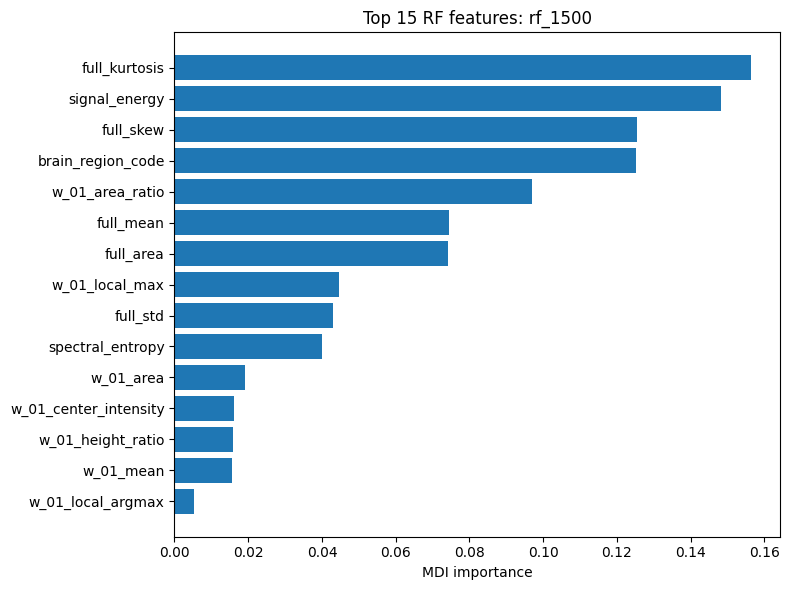

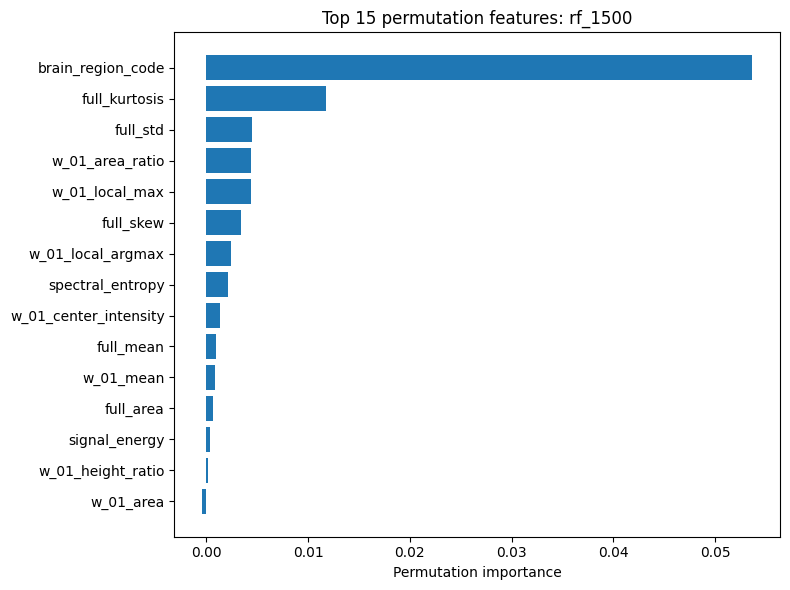


Model: rf_1500
Rows total: 47250
Train: 33061 | Valid: 7097 | Test: 7092
Features used: 15

Metrics summary:


,split,n_rows,accuracy,macro_f1
0,valid,7097,0.583063,0.575384
1,test,7092,0.587422,0.580153



Top MDI importance:


,feature,mdi_importance
0,full_kurtosis,0.156408
1,signal_energy,0.148143
2,full_skew,0.125402
3,brain_region_code,0.125073
4,w_01_area_ratio,0.096992
5,full_mean,0.074500
6,full_area,0.074300
7,w_01_local_max,0.044490
8,full_std,0.042916
9,spectral_entropy,0.040054



Top permutation importance:


,feature,perm_importance_mean,perm_importance_std,importance_split
0,brain_region_code,0.053668,0.002842,valid
1,full_kurtosis,0.011747,0.003284,valid
2,full_std,0.004513,0.001972,valid
3,w_01_area_ratio,0.004439,0.002194,valid
4,w_01_local_max,0.004436,0.001782,valid
5,full_skew,0.003378,0.001093,valid
6,w_01_local_argmax,0.002404,0.000922,valid
7,spectral_entropy,0.002088,0.001507,valid
8,w_01_center_intensity,0.001333,0.001107,valid
9,full_mean,0.000982,0.002231,valid


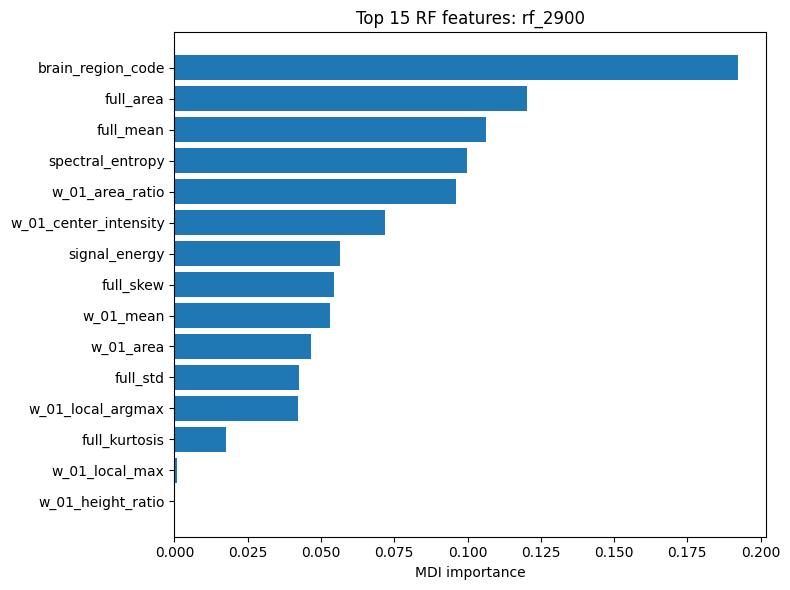

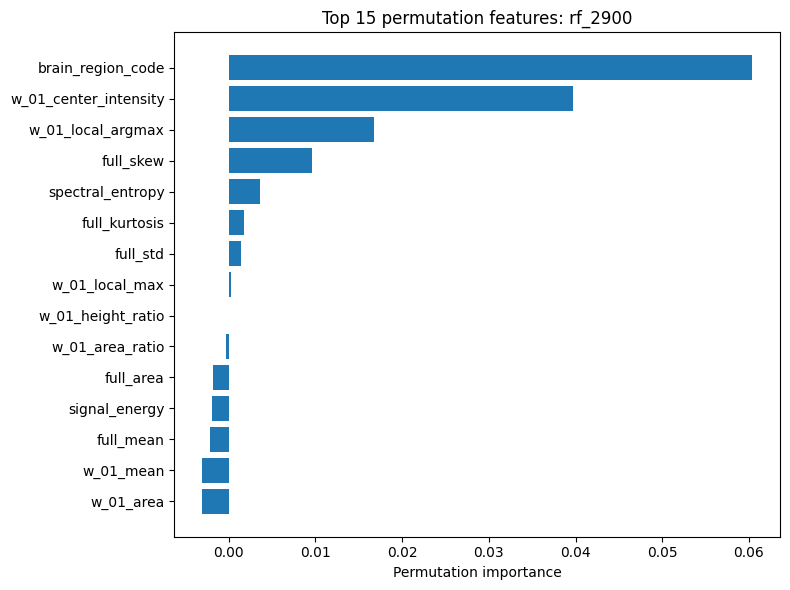


Model: rf_2900
Rows total: 55650
Train: 38951 | Valid: 8348 | Test: 8351
Features used: 15

Metrics summary:


,split,n_rows,accuracy,macro_f1
0,valid,8348,0.555223,0.544164
1,test,8351,0.556939,0.544768



Top MDI importance:


,feature,mdi_importance
0,brain_region_code,0.192166
1,full_area,0.120428
2,full_mean,0.106209
3,spectral_entropy,0.099859
4,w_01_area_ratio,0.095929
5,w_01_center_intensity,0.071684
6,signal_energy,0.056473
7,full_skew,0.054563
8,w_01_mean,0.053037
9,w_01_area,0.046745



Top permutation importance:


,feature,perm_importance_mean,perm_importance_std,importance_split
0,brain_region_code,0.060406,0.001778,valid
1,w_01_center_intensity,0.039755,0.003002,valid
2,w_01_local_argmax,0.016803,0.002220,valid
3,full_skew,0.009584,0.001935,valid
4,spectral_entropy,0.003639,0.001322,valid
5,full_kurtosis,0.001703,0.001598,valid
6,full_std,0.001454,0.001027,valid
7,w_01_local_max,0.000212,0.000277,valid
8,w_01_height_ratio,0.000000,0.000000,valid
9,w_01_area_ratio,-0.000338,0.001297,valid


In [26]:
results_1500 = train_interpretable_rf_for_file(INPUT_1500, "rf_1500")
results_2900 = train_interpretable_rf_for_file(INPUT_2900, "rf_2900")


In [ ]:
summary_rows = []
for band_name, res in [("1500", results_1500), ("2900", results_2900)]:
    m = res["metrics"].copy()
    if not m.empty:
        m.insert(0, "band", band_name)
        summary_rows.append(m)

summary_df = pd.concat(summary_rows, ignore_index=True) if summary_rows else pd.DataFrame()
summary_df.to_csv(OUTPUT_DIR / "rf_two_models_summary.csv", index=False)

print()
print("Combined summary:")
display(summary_df)
print()
print("Output dir:")
print(OUTPUT_DIR)


Combined summary:


,band,split,n_rows,accuracy,macro_f1
0,1500,valid,394,0.888325,0.890180
1,1500,test,394,0.893401,0.891451
2,2900,valid,472,0.779661,0.771576
3,2900,test,473,0.788584,0.784573



Output dir:
/content/drive/MyDrive/raman_rf_output


Test

In [ ]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

# -------------------------
# Paths
# -------------------------
MODEL_DIR = Path("D:\Хакатон\Новая папка\данные/raman_rf_output/rf_1500")
MODEL_PATH = MODEL_DIR / "rf_1500_rf.joblib"
FEATURES_PATH = MODEL_DIR / "feature_list.csv"
METADATA_PATH = MODEL_DIR / "run_metadata.json"

PRED_PATH = Path("D:\Хакатон\Новая папка\данные\pred.csv")  # <-- поменяй путь при необходимости
OUT_DIR = MODEL_DIR / "pred_control_check"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Load artifacts
# -------------------------
model = joblib.load(MODEL_PATH)
feature_cols = pd.read_csv(FEATURES_PATH)["feature"].tolist()

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

label_map = {int(k): v for k, v in meta["label_map"].items()}
inv_label_map = {v: k for k, v in label_map.items()}

if "control" not in inv_label_map:
    raise ValueError("Class 'control' not found in label_map")

control_idx = inv_label_map["control"]

# -------------------------
# Load pred.csv
# -------------------------
df = pd.read_csv(PRED_PATH)

# Если class нет, считаем что весь файл действительно control
if "class" not in df.columns:
    df["class"] = "control"

# Нормализуем class для безопасности
df["class"] = df["class"].astype(str).str.strip().str.lower()

# Проверка, что файл действительно control-only
unique_classes = sorted(df["class"].dropna().unique().tolist())
print("Classes in pred.csv:", unique_classes)

# -------------------------
# Build inference matrix
# -------------------------
X_pred = df.copy()

# Добавляем отсутствующие фичи
for col in feature_cols:
    if col not in X_pred.columns:
        X_pred[col] = np.nan

X_pred = X_pred[feature_cols].copy()

# Приводим к numeric
for col in X_pred.columns:
    X_pred[col] = pd.to_numeric(X_pred[col], errors="coerce")

# Заполняем пропуски медианами по pred.csv, остатки нулями
X_pred = X_pred.fillna(X_pred.median(numeric_only=True))
X_pred = X_pred.fillna(0.0)

# -------------------------
# Predict
# -------------------------
pred_idx = model.predict(X_pred)
proba = model.predict_proba(X_pred)

proba_df = pd.DataFrame(
    proba,
    columns=[f"proba_{label_map[int(c)]}" for c in model.classes_]
)

pred_class = pd.Series(pred_idx).map(label_map)
proba_control = proba_df["proba_control"] if "proba_control" in proba_df.columns else pd.Series(np.nan, index=df.index)

# Истинная метка: control
true_idx = np.full(len(df), control_idx, dtype=int)

is_pred_control = (pred_idx == control_idx).astype(int)

# Для control-only файла accuracy == recall по классу control
control_recall = float(is_pred_control.mean())
false_negative_rate = float(1.0 - control_recall)
mean_proba_control = float(proba_control.mean())
median_proba_control = float(proba_control.median())
low_conf_count = int((proba_control < 0.5).sum())
high_conf_count = int((proba_control >= 0.8).sum())

summary = pd.DataFrame([{
    "n_spectra": int(len(df)),
    "n_pred_control": int(is_pred_control.sum()),
    "n_not_control": int((1 - is_pred_control).sum()),
    "control_recall": control_recall,
    "false_negative_rate": false_negative_rate,
    "mean_proba_control": mean_proba_control,
    "median_proba_control": median_proba_control,
    "n_proba_control_lt_0_50": low_conf_count,
    "n_proba_control_ge_0_80": high_conf_count,
}])

# -------------------------
# Detailed results
# -------------------------
result_cols = []
for c in ["spectrum_id", "brain_region", "band_id", "class"]:
    if c in df.columns:
        result_cols.append(c)

results = df[result_cols].copy() if result_cols else pd.DataFrame(index=df.index)
results["true_class"] = "control"
results["pred_class"] = pred_class.values
results["is_pred_control"] = is_pred_control
results["error_type"] = np.where(results["is_pred_control"] == 1, "TP_control", "FN_control")

for c in proba_df.columns:
    results[c] = proba_df[c].values

results["pred_confidence"] = proba_df.max(axis=1).values

# Ложные отрицания: control -> not control
false_negatives = results[results["is_pred_control"] == 0].copy()
false_negatives = false_negatives.sort_values(
    by="proba_control" if "proba_control" in false_negatives.columns else "pred_confidence",
    ascending=True
)

# Группировка по brain_region, если есть
by_region = None
if "brain_region" in results.columns:
    by_region = (
        results.groupby("brain_region", dropna=False)
        .agg(
            n_spectra=("is_pred_control", "size"),
            control_recall=("is_pred_control", "mean"),
            mean_proba_control=("proba_control", "mean"),
            median_proba_control=("proba_control", "median"),
            n_false_negative=("is_pred_control", lambda s: int((1 - s).sum())),
        )
        .reset_index()
        .sort_values("control_recall", ascending=True)
    )

# -------------------------
# Save
# -------------------------
summary.to_csv(OUT_DIR / "pred_control_summary.csv", index=False)
results.to_csv(OUT_DIR / "pred_control_predictions.csv", index=False)
false_negatives.to_csv(OUT_DIR / "pred_control_false_negatives.csv", index=False)
if by_region is not None:
    by_region.to_csv(OUT_DIR / "pred_control_by_brain_region.csv", index=False)

# -------------------------
# Display
# -------------------------
print()
print("CONTROL CHECK SUMMARY")
display(summary)

print()
print("Prediction distribution")
display(results["pred_class"].value_counts(dropna=False).rename_axis("pred_class").reset_index(name="n"))

if by_region is not None:
    print()
    print("Control quality by brain_region")
    display(by_region)

print()
print("Worst false negatives")
display(false_negatives.head(20))

print()
print("Saved to:", OUT_DIR)


Classes in pred.csv: ['control']

CONTROL CHECK SUMMARY


,n_spectra,n_pred_control,n_not_control,control_recall,false_negative_rate,mean_proba_control,median_proba_control,n_proba_control_lt_0_50,n_proba_control_ge_0_80
0,227850,0,227850,0.0,1.0,0.3683,0.3683,227850,0



Prediction distribution


,pred_class,n
0,exo,227850



Control quality by brain_region


,brain_region,n_spectra,control_recall,mean_proba_control,median_proba_control,n_false_negative
0,cerebellum,227850,0.0,0.3683,0.3683,227850



Worst false negatives


,brain_region,class,true_class,pred_class,is_pred_control,error_type,proba_control,proba_endo,proba_exo,pred_confidence
227839,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713
227838,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713
227837,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713
227836,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713
227835,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713
227834,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713
227833,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713
227832,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713
227831,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713
227830,cerebellum,control,control,exo,0,FN_control,0.3683,0.133988,0.497713,0.497713



Saved to: /content/drive/MyDrive/raman_rf_output/rf_1500/pred_control_check


Делаем модель лучше

In [27]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ========= PATHS =========
BASE_DIR = Path(r"D:\Хакатон\Новая папка\данные")
RF_OUTPUT_DIR = BASE_DIR / "raman_rf_output"

PATH_1500 = BASE_DIR / "1500_preprocessing.csv"
PATH_2900 = BASE_DIR / "2900_preprocessing.csv"
MANIFEST_PATH = BASE_DIR / "manifest.csv"
PRED_SIMPLE_1500_PATH = BASE_DIR / "pred_simple_1500.csv"
PRED_RAW_PATH = BASE_DIR / "pred.csv"

# Для rf_1500 работаем с 1500_preprocessing.csv
DATA_PATH = PATH_1500

RF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def norm_col(c):
    return str(c).strip().lower().replace(" ", "_").replace(".", "_")

df = pd.read_csv(DATA_PATH)
df = df.copy()
df.columns = [norm_col(c) for c in df.columns]

ALIASES = {
    "split": ["split"],
    "target": ["target"],
    "class": ["class"],
    "brain_region": ["brain_region", "brainregion"],
    "brain_region_code": ["brain_region_code", "brainregioncode"],
    "band_id": ["band_id", "bandid"],
    "band_id_code": ["band_id_code", "bandidcode"],
    "spectrum_id": ["spectrum_id", "spectrumid"],
    "source_file_id": ["source_file_id", "sourcefileid"],
    "n_peaks": ["n_peaks", "npeaks"],
    "full_area": ["full_area", "fullarea"],
    "full_mean": ["full_mean", "fullmean"],
    "full_std": ["full_std", "fullstd"],
    "full_skew": ["full_skew", "fullskew"],
    "full_kurtosis": ["full_kurtosis", "fullkurtosis"],
    "signal_energy": ["signal_energy"],
    "n_local_maxima": ["n_local_maxima", "nlocalmaxima"],
    "spectral_entropy": ["spectral_entropy", "spectralentropy"],
    "w_01_area_ratio": ["w_01_area_ratio", "win_01_arearatio"],
    "w_01_local_max": ["w_01_local_max", "win_01_localmax"],
    "w_01_area": ["w_01_area", "win_01_area"],
    "w_01_center_intensity": ["w_01_center_intensity", "win_01_centerintensity"],
    "w_01_height_ratio": ["w_01_height_ratio", "win_01_heightratio"],
    "w_01_mean": ["w_01_mean", "win_01_mean"],
    "w_01_local_argmax": ["w_01_local_argmax", "win_01_argmax"],
}

def pick(alias):
    for c in ALIASES[alias]:
        if c in df.columns:
            return c
    return None

COL = {k: pick(k) for k in ALIASES}

if COL["target"] is None and COL["class"] is not None:
    df["target"] = pd.factorize(df[COL["class"]])[0]
    COL["target"] = "target"

if COL["brain_region_code"] is None and COL["brain_region"] is not None:
    df["brain_region_code"] = pd.factorize(df[COL["brain_region"]])[0]
    COL["brain_region_code"] = "brain_region_code"

if COL["band_id_code"] is None and COL["band_id"] is not None:
    df["band_id_code"] = pd.factorize(df[COL["band_id"]])[0]
    COL["band_id_code"] = "band_id_code"

if COL["split"] is None or COL["target"] is None:
    raise ValueError("Нужны колонки split и target в 1500_preprocessing.csv")

df[COL["split"]] = df[COL["split"]].astype(str).str.lower()

train_mask = df[COL["split"]].eq("train")
valid_mask = df[COL["split"]].eq("valid")
test_mask  = df[COL["split"]].eq("test")

if train_mask.sum() == 0 or valid_mask.sum() == 0:
    raise ValueError("Нужны как минимум train и valid")

RF_BASE = dict(
    n_estimators=120,
    max_depth=4,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

RESULTS = []
FEATURE_SETS = {}

def is_vector_col(c):
    return c.startswith("i_") or re.fullmatch(r"i\d+", c) is not None

def prepare_X(feature_cols):
    feature_cols = [c for c in feature_cols if c in df.columns]
    X = df[feature_cols].select_dtypes(include=np.number).copy()
    X = X.loc[:, X.notna().mean() >= 0.95]
    X = X.loc[:, X.nunique(dropna=False) > 1]
    med = X.loc[train_mask].median(numeric_only=True)
    X = X.fillna(med)
    return X

def run_experiment(name, feature_cols, params=None, eval_test=False, verbose=True):
    X = prepare_X(feature_cols)
    y = df[COL["target"]].astype(int).copy()

    model_params = RF_BASE.copy()
    if params:
        model_params.update(params)

    rf = RandomForestClassifier(**model_params)
    rf.fit(X.loc[train_mask], y.loc[train_mask])

    rows = []
    for split_name, mask in [("valid", valid_mask), ("test", test_mask if eval_test else None)]:
        if mask is None or mask.sum() == 0:
            continue
        pred = rf.predict(X.loc[mask])
        rows.append({
            "model": name,
            "split": split_name,
            "n_rows": int(mask.sum()),
            "accuracy": accuracy_score(y.loc[mask], pred),
            "macro_f1": f1_score(y.loc[mask], pred, average="macro"),
            "n_features": X.shape[1],
        })

    FEATURE_SETS[name] = list(X.columns)
    RESULTS.extend(rows)

    res_df = pd.DataFrame(rows)
    if verbose:
        display(res_df)
        print("Features:", FEATURE_SETS[name])

    return rf, X, res_df

baseline_pref = [
    COL["full_kurtosis"],
    COL["signal_energy"],
    COL["full_skew"],
    COL["brain_region_code"],
    COL["w_01_area_ratio"],
    COL["full_mean"],
    COL["full_area"],
    COL["w_01_local_max"],
    COL["full_std"],
    COL["spectral_entropy"],
    COL["w_01_area"],
    COL["w_01_center_intensity"],
    COL["w_01_height_ratio"],
    COL["w_01_mean"],
    COL["w_01_local_argmax"],
]
baseline_pref = [c for c in baseline_pref if c is not None]

rf_baseline, X_baseline, res_baseline = run_experiment(
    name="baseline_15",
    feature_cols=baseline_pref,
    eval_test=False,
    verbose=True
)

summary = pd.DataFrame(RESULTS).sort_values(["split", "macro_f1"], ascending=[True, False])
display(summary)

summary.to_csv(RF_OUTPUT_DIR / "cell1_baseline_summary.csv", index=False)


,model,split,n_rows,accuracy,macro_f1,n_features
0,baseline_15,valid,7097,0.586868,0.578811,15


Features: ['full_kurtosis', 'signal_energy', 'full_skew', 'brain_region_code', 'w_01_area_ratio', 'full_mean', 'full_area', 'w_01_local_max', 'full_std', 'spectral_entropy', 'w_01_area', 'w_01_center_intensity', 'w_01_height_ratio', 'w_01_mean', 'w_01_local_argmax']


,model,split,n_rows,accuracy,macro_f1,n_features
0,baseline_15,valid,7097,0.586868,0.578811,15


In [28]:
baseline_cols = FEATURE_SETS["baseline_15"].copy()

no_brain_cols = [c for c in baseline_cols if c != COL["brain_region_code"]]

rf_no_brain, X_no_brain, res_no_brain = run_experiment(
    name="no_brain_region",
    feature_cols=no_brain_cols,
    eval_test=False,
    verbose=True
)

cmp = pd.DataFrame(RESULTS)
cmp = cmp[(cmp["split"] == "valid") & (cmp["model"].isin(["baseline_15", "no_brain_region"]))]
cmp = cmp.sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(cmp)

if len(cmp) == 2:
    base_f1 = cmp.loc[cmp["model"] == "baseline_15", "macro_f1"].iloc[0]
    nobr_f1 = cmp.loc[cmp["model"] == "no_brain_region", "macro_f1"].iloc[0]
    print("Delta macro_f1 (no_brain - baseline):", round(nobr_f1 - base_f1, 6))

cmp.to_csv(RF_OUTPUT_DIR / "cell2_no_brain_compare.csv", index=False)


,model,split,n_rows,accuracy,macro_f1,n_features
0,no_brain_region,valid,7097,0.562491,0.549505,14


Features: ['full_kurtosis', 'signal_energy', 'full_skew', 'w_01_area_ratio', 'full_mean', 'full_area', 'w_01_local_max', 'full_std', 'spectral_entropy', 'w_01_area', 'w_01_center_intensity', 'w_01_height_ratio', 'w_01_mean', 'w_01_local_argmax']


,model,split,n_rows,accuracy,macro_f1,n_features
0,baseline_15,valid,7097,0.586868,0.578811,15
1,no_brain_region,valid,7097,0.562491,0.549505,14


Delta macro_f1 (no_brain - baseline): -0.029306


In [29]:
baseline_cols = FEATURE_SETS["baseline_15"].copy()

drop_signal_energy_cols = [c for c in baseline_cols if c != COL["signal_energy"]]

drop_area_mean_energy_cols = [
    c for c in baseline_cols
    if c not in {COL["signal_energy"], COL["full_area"], COL["full_mean"]}
]

spectral_only_cols = [
    c for c in baseline_cols
    if c not in {COL["brain_region_code"], COL["band_id_code"]}
]

for name, cols in {
    "drop_signal_energy": drop_signal_energy_cols,
    "drop_area_mean_energy": drop_area_mean_energy_cols,
    "spectral_only_baseline": spectral_only_cols,
}.items():
    run_experiment(
        name=name,
        feature_cols=cols,
        eval_test=False,
        verbose=False
    )

cmp = pd.DataFrame(RESULTS)
cmp = cmp[
    (cmp["split"] == "valid") &
    (cmp["model"].isin([
        "baseline_15",
        "drop_signal_energy",
        "drop_area_mean_energy",
        "spectral_only_baseline",
    ]))
].sort_values("macro_f1", ascending=False).reset_index(drop=True)

display(cmp)
cmp.to_csv(RF_OUTPUT_DIR / "cell3_ablation_globals.csv", index=False)


,model,split,n_rows,accuracy,macro_f1,n_features
0,drop_signal_energy,valid,7097,0.585740,0.578912,14
1,baseline_15,valid,7097,0.586868,0.578811,15
2,drop_area_mean_energy,valid,7097,0.585177,0.578644,12
3,spectral_only_baseline,valid,7097,0.562491,0.549505,14


In [ ]:
exclude_exact = set(filter(None, [
    COL["spectrum_id"],
    COL["source_file_id"],
    COL["split"],
    COL["class"],
    COL["target"],
]))

expanded_nonvector = []
for c in df.select_dtypes(include=np.number).columns:
    cl = c.lower()
    if c in exclude_exact:
        continue
    if "target" in cl or cl == "class" or cl.startswith("class_"):
        continue
    if is_vector_col(cl):
        continue
    expanded_nonvector.append(c)

expanded_nonvector_no_meta = [
    c for c in expanded_nonvector
    if c not in {COL["brain_region_code"], COL["band_id_code"]}
]

run_experiment(
    name="expanded_nonvector",
    feature_cols=expanded_nonvector,
    eval_test=False,
    verbose=True
)

run_experiment(
    name="expanded_nonvector_no_meta",
    feature_cols=expanded_nonvector_no_meta,
    eval_test=False,
    verbose=True
)

cmp = pd.DataFrame(RESULTS)
cmp = cmp[cmp["split"] == "valid"].sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(cmp.head(20))

cmp.to_csv(RF_OUTPUT_DIR / "cell4_expaned_features.csv", index=False)


,model,split,n_rows,accuracy,macro_f1,n_features
0,expanded_nonvector,valid,7097,0.5825,0.575241,15


Features: ['brain_region_code', 'w_01_local_max', 'w_01_local_argmax', 'w_01_center_intensity', 'w_01_area', 'w_01_mean', 'w_01_area_ratio', 'w_01_height_ratio', 'full_area', 'full_mean', 'full_std', 'full_skew', 'full_kurtosis', 'signal_energy', 'spectral_entropy']


,model,split,n_rows,accuracy,macro_f1,n_features
0,expanded_nonvector_no_meta,valid,7097,0.566296,0.552712,14


Features: ['w_01_local_max', 'w_01_local_argmax', 'w_01_center_intensity', 'w_01_area', 'w_01_mean', 'w_01_area_ratio', 'w_01_height_ratio', 'full_area', 'full_mean', 'full_std', 'full_skew', 'full_kurtosis', 'signal_energy', 'spectral_entropy']


,model,split,n_rows,accuracy,macro_f1,n_features
0,drop_signal_energy,valid,7097,0.585740,0.578912,14
1,baseline_15,valid,7097,0.586868,0.578811,15
2,drop_area_mean_energy,valid,7097,0.585177,0.578644,12
3,expanded_nonvector,valid,7097,0.582500,0.575241,15
4,expanded_nonvector_no_meta,valid,7097,0.566296,0.552712,14
5,no_brain_region,valid,7097,0.562491,0.549505,14
6,spectral_only_baseline,valid,7097,0.562491,0.549505,14


In [31]:
results_df = pd.DataFrame(RESULTS)

valid_rank = (
    results_df[results_df["split"] == "valid"]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

top_feature_sets = valid_rank["model"].drop_duplicates().head(3).tolist()
print("Top feature sets for tuning:", top_feature_sets)

param_grid = [
    {"n_estimators": 120, "max_depth": 4, "min_samples_leaf": 10, "min_samples_split": 20, "max_features": "sqrt"},
    {"n_estimators": 250, "max_depth": 4, "min_samples_leaf": 10, "min_samples_split": 20, "max_features": "sqrt"},
    {"n_estimators": 250, "max_depth": 6, "min_samples_leaf": 5,  "min_samples_split": 10, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 6, "min_samples_leaf": 5,  "min_samples_split": 10, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 8, "min_samples_leaf": 3,  "min_samples_split": 10, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": None, "min_samples_leaf": 5, "min_samples_split": 20, "max_features": 0.5},
]

tuning_rows = []

for base_model_name in top_feature_sets:
    cols = FEATURE_SETS[base_model_name]
    for i, params in enumerate(param_grid, start=1):
        tune_name = f"{base_model_name}__tune_{i}"
        _, _, res = run_experiment(
            name=tune_name,
            feature_cols=cols,
            params=params,
            eval_test=False,
            verbose=False
        )
        vr = res.loc[res["split"] == "valid"].iloc[0].to_dict()
        tuning_rows.append({
            "base_model": base_model_name,
            "trial": i,
            "valid_accuracy": vr["accuracy"],
            "valid_macro_f1": vr["macro_f1"],
            "n_features": vr["n_features"],
            **params
        })

tuning_df = pd.DataFrame(tuning_rows).sort_values("valid_macro_f1", ascending=False).reset_index(drop=True)
display(tuning_df.head(15))
tuning_df.to_csv(RF_OUTPUT_DIR / "cell5_tuning_rank.csv", index=False)

best_row = tuning_df.iloc[0]
best_feature_set_name = best_row["base_model"]
best_params = {
    "n_estimators": int(best_row["n_estimators"]),
    "max_depth": None if pd.isna(best_row["max_depth"]) else int(best_row["max_depth"]),
    "min_samples_leaf": int(best_row["min_samples_leaf"]),
    "min_samples_split": int(best_row["min_samples_split"]),
    "max_features": best_row["max_features"],
}

rf_best, X_best, final_res = run_experiment(
    name="best_final",
    feature_cols=FEATURE_SETS[best_feature_set_name],
    params=best_params,
    eval_test=True,
    verbose=True
)

y = df[COL["target"]].astype(int)
labels = sorted(y.dropna().unique().tolist())

if COL["class"] is not None:
    label_map = (
        df[[COL["target"], COL["class"]]]
        .dropna()
        .drop_duplicates()
        .groupby(COL["target"])[COL["class"]]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
        .to_dict()
    )
    target_names = [str(label_map.get(lbl, lbl)) for lbl in labels]
else:
    target_names = [str(lbl) for lbl in labels]

for split_name, mask in [("valid", valid_mask), ("test", test_mask)]:
    if mask.sum() == 0:
        continue

    pred = rf_best.predict(X_best.loc[mask])

    print(f"\n===== {split_name.upper()} =====")
    print("accuracy:", round(accuracy_score(y.loc[mask], pred), 6))
    print("macro_f1:", round(f1_score(y.loc[mask], pred, average='macro'), 6))
    print(classification_report(
        y.loc[mask],
        pred,
        labels=labels,
        target_names=target_names,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y.loc[mask], pred, labels=labels)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{x}" for x in target_names],
        columns=[f"pred_{x}" for x in target_names]
    )
    display(cm_df)
    cm_df.to_csv(RF_OUTPUT_DIR / f"best_final_cm_{split_name}.csv")

final_board = pd.DataFrame(RESULTS)
final_board = final_board.sort_values(["split", "macro_f1"], ascending=[True, False])
display(final_board[final_board["split"] == "valid"].head(20))
final_board.to_csv(RF_OUTPUT_DIR / "all_experiments_summary.csv", index=False)


Top feature sets for tuning: ['drop_signal_energy', 'baseline_15', 'drop_area_mean_energy']


,base_model,trial,valid_accuracy,valid_macro_f1,n_features,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features
0,drop_area_mean_energy,6,0.707341,0.703202,12,400,NaN,5,20,0.5
1,drop_signal_energy,6,0.705650,0.701455,14,400,NaN,5,20,0.5
2,baseline_15,6,0.704805,0.700553,15,400,NaN,5,20,0.5
3,drop_area_mean_energy,5,0.677610,0.672619,12,400,8.0,3,10,sqrt
4,drop_signal_energy,5,0.672256,0.666835,14,400,8.0,3,10,sqrt
5,baseline_15,5,0.671270,0.665556,15,400,8.0,3,10,sqrt
6,drop_area_mean_energy,3,0.648443,0.640906,12,250,6.0,5,10,sqrt
7,drop_area_mean_energy,4,0.648020,0.640394,12,400,6.0,5,10,sqrt
8,drop_signal_energy,4,0.644075,0.635714,14,400,6.0,5,10,sqrt
9,drop_signal_energy,3,0.643230,0.635120,14,250,6.0,5,10,sqrt


,model,split,n_rows,accuracy,macro_f1,n_features
0,best_final,valid,7097,0.707341,0.703202,12
1,best_final,test,7092,0.718697,0.714886,12


Features: ['full_kurtosis', 'full_skew', 'brain_region_code', 'w_01_area_ratio', 'w_01_local_max', 'full_std', 'spectral_entropy', 'w_01_area', 'w_01_center_intensity', 'w_01_height_ratio', 'w_01_mean', 'w_01_local_argmax']

===== VALID =====
accuracy: 0.707341
macro_f1: 0.703202
              precision    recall  f1-score   support

     control     0.6835    0.6837    0.6836      2441
        endo     0.6501    0.6584    0.6542      2046
         exo     0.7758    0.7678    0.7718      2610

    accuracy                         0.7073      7097
   macro avg     0.7031    0.7033    0.7032      7097
weighted avg     0.7078    0.7073    0.7076      7097



,pred_control,pred_endo,pred_exo
true_control,1669,451,321
true_endo,441,1347,258
true_exo,332,274,2004



===== TEST =====
accuracy: 0.718697
macro_f1: 0.714886
              precision    recall  f1-score   support

     control     0.7035    0.6839    0.6935      2442
        endo     0.6673    0.6817    0.6744      2042
         exo     0.7732    0.7803    0.7767      2608

    accuracy                         0.7187      7092
   macro avg     0.7146    0.7153    0.7149      7092
weighted avg     0.7187    0.7187    0.7186      7092



,pred_control,pred_endo,pred_exo
true_control,1670,428,344
true_endo,397,1392,253
true_exo,307,266,2035


,model,split,n_rows,accuracy,macro_f1,n_features
24,drop_area_mean_energy__tune_6,valid,7097,0.707341,0.703202,12
25,best_final,valid,7097,0.707341,0.703202,12
12,drop_signal_energy__tune_6,valid,7097,0.705650,0.701455,14
18,baseline_15__tune_6,valid,7097,0.704805,0.700553,15
23,drop_area_mean_energy__tune_5,valid,7097,0.677610,0.672619,12
11,drop_signal_energy__tune_5,valid,7097,0.672256,0.666835,14
17,baseline_15__tune_5,valid,7097,0.671270,0.665556,15
21,drop_area_mean_energy__tune_3,valid,7097,0.648443,0.640906,12
22,drop_area_mean_energy__tune_4,valid,7097,0.648020,0.640394,12
10,drop_signal_energy__tune_4,valid,7097,0.644075,0.635714,14


Еще более улучшение модели и работа с моделью

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

best_features = FEATURE_SETS.get("best_final", [
    "full_kurtosis",
    "full_skew",
    "brain_region_code",
    "w_01_area_ratio",
    "w_01_local_max",
    "full_std",
    "spectral_entropy",
    "w_01_area",
    "w_01_center_intensity",
    "w_01_height_ratio",
    "w_01_mean",
    "w_01_local_argmax",
])

best_features = [c for c in best_features if c in df.columns]

best_params = dict(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=20,
    max_features=0.5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

X_best = prepare_X(best_features)
y = df[COL["target"]].astype(int).copy()

rf_best_pi = RandomForestClassifier(**best_params)
rf_best_pi.fit(X_best.loc[train_mask], y.loc[train_mask])

for split_name, mask in [("valid", valid_mask), ("test", test_mask)]:
    if mask.sum() == 0:
        continue
    pred = rf_best_pi.predict(X_best.loc[mask])
    print(f"\n===== {split_name.upper()} =====")
    print("accuracy:", round(accuracy_score(y.loc[mask], pred), 6))
    print("macro_f1:", round(f1_score(y.loc[mask], pred, average="macro"), 6))

mdi_df = (
    pd.DataFrame({
        "feature": X_best.columns,
        "mdi_importance": rf_best_pi.feature_importances_,
    })
    .sort_values("mdi_importance", ascending=False)
    .reset_index(drop=True)
)

perm = permutation_importance(
    rf_best_pi,
    X_best.loc[valid_mask],
    y.loc[valid_mask],
    n_repeats=15,
    random_state=42,
    n_jobs=-1,
    scoring="f1_macro",
)

perm_df = (
    pd.DataFrame({
        "feature": X_best.columns,
        "perm_importance_mean": perm.importances_mean,
        "perm_importance_std": perm.importances_std,
    })
    .sort_values("perm_importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("\nTop MDI importance")
display(mdi_df)

print("\nTop permutation importance")
display(perm_df)

mdi_df.to_csv(RF_OUTPUT_DIR / "best_final_mdi_importance.csv", index=False)
perm_df.to_csv(RF_OUTPUT_DIR / "best_final_permutation_importance.csv", index=False)


===== VALID =====
accuracy: 0.707341
macro_f1: 0.703202

===== TEST =====
accuracy: 0.718697
macro_f1: 0.714886

Top MDI importance


,feature,mdi_importance
0,full_skew,0.131512
1,full_kurtosis,0.126022
2,brain_region_code,0.118991
3,w_01_local_max,0.117919
4,spectral_entropy,0.105205
5,w_01_area_ratio,0.103938
6,full_std,0.092629
7,w_01_center_intensity,0.072128
8,w_01_mean,0.050549
9,w_01_area,0.044566



Top permutation importance


,feature,perm_importance_mean,perm_importance_std
0,brain_region_code,0.173141,0.004301
1,w_01_local_max,0.071191,0.003468
2,full_kurtosis,0.055013,0.003446
3,full_std,0.038509,0.002578
4,spectral_entropy,0.036112,0.002453
5,w_01_area_ratio,0.031838,0.002539
6,full_skew,0.024043,0.002810
7,w_01_local_argmax,0.020293,0.002097
8,w_01_center_intensity,0.018149,0.001837
9,w_01_mean,0.012985,0.002483


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

best_features = FEATURE_SETS.get("best_final", [
    "full_kurtosis",
    "full_skew",
    "brain_region_code",
    "w_01_area_ratio",
    "w_01_local_max",
    "full_std",
    "spectral_entropy",
    "w_01_area",
    "w_01_center_intensity",
    "w_01_height_ratio",
    "w_01_mean",
    "w_01_local_argmax",
])

if "brain_region_code" not in best_features:
    print("brain_region_code уже нет в best_final")
else:
    best_no_brain = [c for c in best_features if c != "brain_region_code"]

    best_params = dict(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=5,
        min_samples_split=20,
        max_features=0.5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    X_base = prepare_X(best_features)
    X_nobr = prepare_X(best_no_brain)
    y = df[COL["target"]].astype(int).copy()

    rf_base_cmp = RandomForestClassifier(**best_params)
    rf_nobr = RandomForestClassifier(**best_params)

    rf_base_cmp.fit(X_base.loc[train_mask], y.loc[train_mask])
    rf_nobr.fit(X_nobr.loc[train_mask], y.loc[train_mask])

    rows = []

    for model_name, model, Xmat in [
        ("best_final_with_brain", rf_base_cmp, X_base),
        ("best_final_no_brain", rf_nobr, X_nobr),
    ]:
        for split_name, mask in [("valid", valid_mask), ("test", test_mask)]:
            if mask.sum() == 0:
                continue
            pred = model.predict(Xmat.loc[mask])
            rows.append({
                "model": model_name,
                "split": split_name,
                "n_rows": int(mask.sum()),
                "accuracy": accuracy_score(y.loc[mask], pred),
                "macro_f1": f1_score(y.loc[mask], pred, average="macro"),
                "n_features": Xmat.shape[1],
            })

    compare_df = pd.DataFrame(rows).sort_values(["split", "macro_f1"], ascending=[True, False]).reset_index(drop=True)
    display(compare_df)

    if COL["class"] is not None:
        label_map = (
            df[[COL["target"], COL["class"]]]
            .dropna()
            .drop_duplicates()
            .groupby(COL["target"])[COL["class"]]
            .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
            .to_dict()
        )
        labels = sorted(y.dropna().unique().tolist())
        target_names = [str(label_map.get(lbl, lbl)) for lbl in labels]

        for split_name, mask in [("valid", valid_mask), ("test", test_mask)]:
            if mask.sum() == 0:
                continue
            pred = rf_nobr.predict(X_nobr.loc[mask])

            print(f"\n===== NO_BRAIN {split_name.upper()} =====")
            print("accuracy:", round(accuracy_score(y.loc[mask], pred), 6))
            print("macro_f1:", round(f1_score(y.loc[mask], pred, average='macro'), 6))
            print(classification_report(
                y.loc[mask],
                pred,
                labels=labels,
                target_names=target_names,
                digits=4,
                zero_division=0
            ))

            cm = confusion_matrix(y.loc[mask], pred, labels=labels)
            cm_df = pd.DataFrame(
                cm,
                index=[f"true_{x}" for x in target_names],
                columns=[f"pred_{x}" for x in target_names]
            )
            display(cm_df)
            cm_df.to_csv(RF_OUTPUT_DIR / f"best_final_no_brain_cm_{split_name}.csv")

    compare_df.to_csv(RF_OUTPUT_DIR / "best_final_vs_no_brain.csv", index=False)


,model,split,n_rows,accuracy,macro_f1,n_features
0,best_final_with_brain,test,7092,0.718697,0.714886,12
1,best_final_no_brain,test,7092,0.617456,0.611255,11
2,best_final_with_brain,valid,7097,0.707341,0.703202,12
3,best_final_no_brain,valid,7097,0.620826,0.613751,11



===== NO_BRAIN VALID =====
accuracy: 0.620826
macro_f1: 0.613751
              precision    recall  f1-score   support

     control     0.6011    0.5944    0.5977      2441
        endo     0.5579    0.5323    0.5448      2046
         exo     0.6833    0.7149    0.6987      2610

    accuracy                         0.6208      7097
   macro avg     0.6141    0.6139    0.6138      7097
weighted avg     0.6189    0.6208    0.6196      7097



,pred_control,pred_endo,pred_exo
true_control,1451,520,470
true_endo,562,1089,395
true_exo,401,343,1866



===== NO_BRAIN TEST =====
accuracy: 0.617456
macro_f1: 0.611255
              precision    recall  f1-score   support

     control     0.6076    0.5872    0.5973      2442
        endo     0.5593    0.5431    0.5511      2042
         exo     0.6679    0.7040    0.6855      2608

    accuracy                         0.6175      7092
   macro avg     0.6116    0.6114    0.6113      7092
weighted avg     0.6159    0.6175    0.6164      7092



,pred_control,pred_endo,pred_exo
true_control,1434,498,510
true_endo,530,1109,403
true_exo,396,376,1836


In [37]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# =========================
# PATHS: полностью автономно
# =========================
BASE_DIR = Path(r"D:\Хакатон\Новая папка\данные")
RF_OUTPUT_DIR = BASE_DIR / "raman_rf_output"
PATH_1500 = BASE_DIR / "1500_preprocessing.csv"
PATH_2900 = BASE_DIR / "2900_preprocessing.csv"

RF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def norm_col(c):
    return str(c).strip().lower().replace(" ", "_").replace(".", "_")

def is_vector_col(c):
    c = str(c).lower()
    return c.startswith("i_") or re.fullmatch(r"i\d+", c) is not None

def load_df(path):
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")
    x = pd.read_csv(path).copy()
    x.columns = [norm_col(c) for c in x.columns]
    return x

def ensure_basic_codes(x):
    if "target" not in x.columns and "class" in x.columns:
        x["target"] = pd.factorize(x["class"])[0]

    if "brainregion" in x.columns and "brain_region" not in x.columns:
        x["brain_region"] = x["brainregion"]
    if "brainregioncode" in x.columns and "brain_region_code" not in x.columns:
        x["brain_region_code"] = x["brainregioncode"]
    if "sourcefileid" in x.columns and "source_file_id" not in x.columns:
        x["source_file_id"] = x["sourcefileid"]
    if "spectrumid" in x.columns and "spectrum_id" not in x.columns:
        x["spectrum_id"] = x["spectrumid"]
    if "bandid" in x.columns and "band_id" not in x.columns:
        x["band_id"] = x["bandid"]
    if "bandidcode" in x.columns and "band_id_code" not in x.columns:
        x["band_id_code"] = x["bandidcode"]

    if "brain_region_code" not in x.columns and "brain_region" in x.columns:
        x["brain_region_code"] = pd.factorize(x["brain_region"])[0]

    return x

d1500 = ensure_basic_codes(load_df(PATH_1500))
d2900 = ensure_basic_codes(load_df(PATH_2900))

print("1500 shape:", d1500.shape)
print("2900 shape:", d2900.shape)
print("\n1500 cols sample:", d1500.columns[:30].tolist())
print("\n2900 cols sample:", d2900.columns[:30].tolist())

for col in ["split", "target"]:
    if col not in d1500.columns:
        raise ValueError(f"В 1500_preprocessing.csv нет колонки '{col}'")
    if col not in d2900.columns:
        raise ValueError(f"В 2900_preprocessing.csv нет колонки '{col}'")

d1500["split"] = d1500["split"].astype(str).str.lower()
d2900["split"] = d2900["split"].astype(str).str.lower()

# =========================
# Признаки 1500: твой champion
# =========================
features_1500 = [
    "full_kurtosis",
    "full_skew",
    "brain_region_code",
    "w_01_area_ratio",
    "w_01_local_max",
    "full_std",
    "spectral_entropy",
    "w_01_area",
    "w_01_center_intensity",
    "w_01_height_ratio",
    "w_01_mean",
    "w_01_local_argmax",
]
features_1500 = [c for c in features_1500 if c in d1500.columns]

if len(features_1500) == 0:
    raise ValueError("Не найдено ни одного признака champion в 1500_preprocessing.csv")

# =========================
# Признаки 2900: numeric non-vector
# =========================
exclude_2900 = {
    "target", "class", "split",
    "spectrum_id", "spectrumid",
    "source_file_id", "sourcefileid",
    "brain_region", "brainregion",
    "band_id", "bandid",
    "band_id_code", "bandidcode",
}

features_2900 = []
for c in d2900.select_dtypes(include=np.number).columns:
    cl = c.lower()
    if c in exclude_2900:
        continue
    if "target" in cl or "class" in cl:
        continue
    if is_vector_col(cl):
        continue
    features_2900.append(c)

if len(features_2900) == 0:
    raise ValueError("В 2900_preprocessing.csv не найдено numeric non-vector признаков")

print("\nN features_1500:", len(features_1500))
print("N features_2900:", len(features_2900))

# =========================
# Ключ склейки
# =========================
preferred_ids = [
    "pair_id", "sample_id", "patient_id", "record_id",
    "specimen_id", "spectrum_id", "source_file_id"
]

common_ids = [c for c in preferred_ids if c in d1500.columns and c in d2900.columns]
print("\nCommon preferred ids:", common_ids)

if common_ids:
    merge_on = common_ids + [c for c in ["split", "target"] if c in d1500.columns and c in d2900.columns]
    left = d1500.copy()
    right = d2900.copy()
else:
    fallback_group = [c for c in ["split", "target", "class", "brain_region"] if c in d1500.columns and c in d2900.columns]
    print("Fallback group:", fallback_group)

    if len(fallback_group) == 0:
        raise ValueError("Не найден общий ключ для fusion. Нужен настоящий ID образца или хотя бы общие meta-колонки.")

    left = d1500.sort_values(fallback_group).copy()
    right = d2900.sort_values(fallback_group).copy()

    left["_pair_n"] = left.groupby(fallback_group).cumcount()
    right["_pair_n"] = right.groupby(fallback_group).cumcount()
    merge_on = fallback_group + ["_pair_n"]

print("merge_on:", merge_on)

# =========================
# Подготовка таблиц к merge
# =========================
left_keep = merge_on + [c for c in features_1500 if c in left.columns]
right_keep = merge_on + [c for c in features_2900 if c in right.columns]

left_small = left[left_keep].copy()
right_small = right[right_keep].copy()

left_small = left_small.rename(columns={c: f"f1500__{c}" for c in features_1500 if c in left_small.columns})
right_small = right_small.rename(columns={c: f"f2900__{c}" for c in features_2900 if c in right_small.columns})

fusion = left_small.merge(right_small, on=merge_on, how="inner")

print("\nFusion rows after merge:", len(fusion))
if fusion.empty:
    raise ValueError(
        "fusion пустой после merge. Почти наверняка неверный ключ склейки. "
        "Нужен общий sample/pair/source ID для 1500 и 2900."
    )

# =========================
# Возвращаем метаданные
# =========================
meta_cols = [c for c in ["split", "target", "class", "brain_region", "brain_region_code"] if c in d1500.columns]
meta_base_cols = list(dict.fromkeys(merge_on + meta_cols))

meta_base = d1500[meta_base_cols].copy().drop_duplicates(subset=merge_on)
fusion = fusion.merge(meta_base, on=merge_on, how="left")

if "split" not in fusion.columns or "target" not in fusion.columns:
    raise ValueError("После merge потерялись split/target")

fusion_feature_cols = [c for c in fusion.columns if c.startswith("f1500__") or c.startswith("f2900__")]
if len(fusion_feature_cols) == 0:
    raise ValueError("После merge не осталось fusion-признаков")

X = fusion[fusion_feature_cols].select_dtypes(include=np.number).copy()
X = X.loc[:, X.notna().mean() >= 0.95]
X = X.loc[:, X.nunique(dropna=False) > 1]

train_mask_f = fusion["split"].eq("train")
valid_mask_f = fusion["split"].eq("valid")
test_mask_f  = fusion["split"].eq("test")

print("\nSplit counts in fusion:")
print(fusion["split"].value_counts(dropna=False))

if train_mask_f.sum() == 0 or valid_mask_f.sum() == 0:
    raise ValueError("В fusion нет train или valid строк")

med = X.loc[train_mask_f].median(numeric_only=True)
X = X.fillna(med)

y = fusion["target"].astype(int)

fusion_params = dict(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=20,
    max_features=0.35,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_fusion = RandomForestClassifier(**fusion_params)
rf_fusion.fit(X.loc[train_mask_f], y.loc[train_mask_f])

rows = []
for split_name, mask in [("valid", valid_mask_f), ("test", test_mask_f)]:
    if mask.sum() == 0:
        continue
    pred = rf_fusion.predict(X.loc[mask])
    rows.append({
        "model": "fusion_1500_2900",
        "split": split_name,
        "n_rows": int(mask.sum()),
        "accuracy": accuracy_score(y.loc[mask], pred),
        "macro_f1": f1_score(y.loc[mask], pred, average="macro"),
        "n_features": X.shape[1],
    })

fusion_res = pd.DataFrame(rows)
display(fusion_res)

print("\nRows 1500:", len(d1500))
print("Rows 2900:", len(d2900))
print("Rows fusion:", len(fusion))
print("Used features before filtering:", len(fusion_feature_cols))
print("Kept numeric robust features:", X.shape[1])

if "class" in fusion.columns:
    label_map = (
        fusion[["target", "class"]]
        .dropna()
        .drop_duplicates()
        .groupby("target")["class"]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
        .to_dict()
    )
    labels = sorted(y.dropna().unique().tolist())
    target_names = [str(label_map.get(lbl, lbl)) for lbl in labels]

    for split_name, mask in [("valid", valid_mask_f), ("test", test_mask_f)]:
        if mask.sum() == 0:
            continue
        pred = rf_fusion.predict(X.loc[mask])

        print(f"\n===== FUSION {split_name.upper()} =====")
        print("accuracy:", round(accuracy_score(y.loc[mask], pred), 6))
        print("macro_f1:", round(f1_score(y.loc[mask], pred, average='macro'), 6))
        print(classification_report(
            y.loc[mask],
            pred,
            labels=labels,
            target_names=target_names,
            digits=4,
            zero_division=0
        ))

fusion_res.to_csv(RF_OUTPUT_DIR / "fusion_1500_2900_summary.csv", index=False)
pd.DataFrame({"feature": X.columns}).to_csv(RF_OUTPUT_DIR / "fusion_1500_2900_features.csv", index=False)

1500 shape: (47250, 490)
2900 shape: (55650, 354)

1500 cols sample: ['spectrum_id', 'brain_region', 'brain_region_code', 'band_id', 'band_id_code', 'class', 'target', 'split', 'n_peaks', 'main_peak_position', 'main_peak_height', 'peak_01_position', 'peak_01_height', 'peak_01_prominence', 'peak_01_width', 'peak_01_local_area', 'peak_02_position', 'peak_02_height', 'peak_02_prominence', 'peak_02_width', 'peak_02_local_area', 'peak_03_position', 'peak_03_height', 'peak_03_prominence', 'peak_03_width', 'peak_03_local_area', 'peak_04_position', 'peak_04_height', 'peak_04_prominence', 'peak_04_width']

2900 cols sample: ['spectrum_id', 'brain_region', 'brain_region_code', 'band_id', 'band_id_code', 'class', 'target', 'split', 'n_peaks', 'main_peak_position', 'main_peak_height', 'peak_01_position', 'peak_01_height', 'peak_01_prominence', 'peak_01_width', 'peak_01_local_area', 'peak_02_position', 'peak_02_height', 'peak_02_prominence', 'peak_02_width', 'peak_02_local_area', 'peak_03_position'

,model,split,n_rows,accuracy,macro_f1,n_features
0,fusion_1500_2900,valid,1167,0.844901,0.819344,27
1,fusion_1500_2900,test,1212,0.860561,0.847034,27



Rows 1500: 47250
Rows 2900: 55650
Rows fusion: 22505
Used features before filtering: 60
Kept numeric robust features: 27

===== FUSION VALID =====
accuracy: 0.844901
macro_f1: 0.819344
              precision    recall  f1-score   support

     control     0.9141    0.8663    0.8896       688
        endo     0.7148    0.7787    0.7454       235
         exo     0.7992    0.8484    0.8231       244

    accuracy                         0.8449      1167
   macro avg     0.8094    0.8311    0.8193      1167
weighted avg     0.8500    0.8449    0.8466      1167


===== FUSION TEST =====
accuracy: 0.860561
macro_f1: 0.847034
              precision    recall  f1-score   support

     control     0.9196    0.8640    0.8910       662
        endo     0.7587    0.8189    0.7877       265
         exo     0.8355    0.8912    0.8625       285

    accuracy                         0.8606      1212
   macro avg     0.8380    0.8580    0.8470      1212
weighted avg     0.8647    0.8606    0.8617 

Сохр. лучшей модели

In [38]:
import re
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

BASE_DIR = Path(r"D:\Хакатон\Новая папка\данные")
RF_OUTPUT_DIR = BASE_DIR / "raman_rf_output"
TRAIN_PATH = BASE_DIR / "1500_preprocessing.csv"
MODEL_PATH = RF_OUTPUT_DIR / "rf_1500_best_final.joblib"

RF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def norm_col(c):
    return str(c).strip().lower().replace(" ", "_").replace(".", "_")

df = pd.read_csv(TRAIN_PATH).copy()
df.columns = [norm_col(c) for c in df.columns]

if "brainregion" in df.columns and "brain_region" not in df.columns:
    df["brain_region"] = df["brainregion"]
if "brainregioncode" in df.columns and "brain_region_code" not in df.columns:
    df["brain_region_code"] = df["brainregioncode"]
if "sourcefileid" in df.columns and "source_file_id" not in df.columns:
    df["source_file_id"] = df["sourcefileid"]
if "spectrumid" in df.columns and "spectrum_id" not in df.columns:
    df["spectrum_id"] = df["spectrumid"]
if "bandid" in df.columns and "band_id" not in df.columns:
    df["band_id"] = df["bandid"]
if "bandidcode" in df.columns and "band_id_code" not in df.columns:
    df["band_id_code"] = df["bandidcode"]

if "target" not in df.columns and "class" in df.columns:
    df["target"] = pd.factorize(df["class"])[0]
if "brain_region_code" not in df.columns and "brain_region" in df.columns:
    df["brain_region_code"] = pd.factorize(df["brain_region"])[0]

for need in ["split", "target"]:
    if need not in df.columns:
        raise ValueError(f"В {TRAIN_PATH.name} нет колонки {need}")

df["split"] = df["split"].astype(str).str.lower()

train_mask = df["split"].eq("train")
valid_mask = df["split"].eq("valid")
test_mask  = df["split"].eq("test")

best_features = [
    "full_kurtosis",
    "full_skew",
    "brain_region_code",
    "w_01_area_ratio",
    "w_01_local_max",
    "full_std",
    "spectral_entropy",
    "w_01_area",
    "w_01_center_intensity",
    "w_01_height_ratio",
    "w_01_mean",
    "w_01_local_argmax",
]
best_features = [c for c in best_features if c in df.columns]

if len(best_features) == 0:
    raise ValueError("Не найдены признаки best_final в 1500_preprocessing.csv")

X = df[best_features].select_dtypes(include=np.number).copy()
X = X.loc[:, X.notna().mean() >= 0.95]
X = X.loc[:, X.nunique(dropna=False) > 1]

# Вариант для production: дообучаем на train+valid после выбора гиперпараметров
refit_mask = train_mask | valid_mask
train_medians = X.loc[refit_mask].median(numeric_only=True)
X = X.fillna(train_medians)

y = df["target"].astype(int).copy()

best_params = dict(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=20,
    max_features=0.5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf = RandomForestClassifier(**best_params)
rf.fit(X.loc[refit_mask], y.loc[refit_mask])

rows = []
for split_name, mask in [("train", train_mask), ("valid", valid_mask), ("test", test_mask)]:
    if mask.sum() == 0:
        continue
    pred = rf.predict(X.loc[mask])
    rows.append({
        "split": split_name,
        "n_rows": int(mask.sum()),
        "accuracy": accuracy_score(y.loc[mask], pred),
        "macro_f1": f1_score(y.loc[mask], pred, average="macro"),
    })

metrics_df = pd.DataFrame(rows)
print(metrics_df)

label_map = None
if "class" in df.columns:
    label_map = (
        df[["target", "class"]]
        .dropna()
        .drop_duplicates()
        .groupby("target")["class"]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
        .to_dict()
    )

brain_region_encoder = None
if "brain_region" in df.columns and "brain_region_code" in df.columns:
    tmp = (
        df[["brain_region", "brain_region_code"]]
        .dropna()
        .drop_duplicates()
        .sort_values("brain_region_code")
    )
    brain_region_encoder = dict(zip(tmp["brain_region"].astype(str), tmp["brain_region_code"].astype(int)))

bundle = {
    "model_name": "rf_1500_best_final",
    "band": "1500",
    "model": rf,
    "feature_columns": list(X.columns),
    "train_medians": train_medians.to_dict(),
    "label_map": label_map,
    "brain_region_encoder": brain_region_encoder,
    "params": best_params,
    "train_path": str(TRAIN_PATH),
}

joblib.dump(bundle, MODEL_PATH)
metrics_df.to_csv(RF_OUTPUT_DIR / "rf_1500_best_final_refit_metrics.csv", index=False)

print("Saved model:", MODEL_PATH)
print("Saved metrics:", RF_OUTPUT_DIR / "rf_1500_best_final_refit_metrics.csv")
print("Features:", list(X.columns))

   split  n_rows  accuracy  macro_f1
0  train   33061  0.847917  0.846416
1  valid    7097  0.844582  0.843251
2   test    7092  0.720389  0.716364
Saved model: D:\Хакатон\Новая папка\данные\raman_rf_output\rf_1500_best_final.joblib
Saved metrics: D:\Хакатон\Новая папка\данные\raman_rf_output\rf_1500_best_final_refit_metrics.csv
Features: ['full_kurtosis', 'full_skew', 'brain_region_code', 'w_01_area_ratio', 'w_01_local_max', 'full_std', 'spectral_entropy', 'w_01_area', 'w_01_center_intensity', 'w_01_height_ratio', 'w_01_mean', 'w_01_local_argmax']


сохранение rf 2900

In [41]:
import re
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

BASE_DIR = Path(r"D:\Хакатон\Новая папка\данные")
RF_OUTPUT_DIR = BASE_DIR / "raman_rf_output"
TRAIN_PATH = BASE_DIR / "2900_preprocessing.csv"
MODEL_PATH = RF_OUTPUT_DIR / "rf_2900_best_final.joblib"

RF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def norm_col(c):
    return str(c).strip().lower().replace(" ", "_").replace(".", "_")

def is_vector_col(c):
    c = str(c).lower()
    return c.startswith("i_") or re.fullmatch(r"i\d+", c) is not None

def alias_columns(df):
    df = df.copy()
    renames = {}
    if "brainregion" in df.columns and "brain_region" not in df.columns:
        renames["brainregion"] = "brain_region"
    if "brainregioncode" in df.columns and "brain_region_code" not in df.columns:
        renames["brainregioncode"] = "brain_region_code"
    if "sourcefileid" in df.columns and "source_file_id" not in df.columns:
        renames["sourcefileid"] = "source_file_id"
    if "spectrumid" in df.columns and "spectrum_id" not in df.columns:
        renames["spectrumid"] = "spectrum_id"
    if "bandid" in df.columns and "band_id" not in df.columns:
        renames["bandid"] = "band_id"
    if "bandidcode" in df.columns and "band_id_code" not in df.columns:
        renames["bandidcode"] = "band_id_code"
    if renames:
        df = df.rename(columns=renames)
    return df

def make_feature_sets(df):
    bad_exact = {
        "spectrum_id", "source_file_id", "split",
        "class", "target",
        "brain_region", "band_id",
    }

    numeric_safe = []
    for c in df.columns:
        cl = c.lower()
        if c in bad_exact:
            continue
        if "target" in cl or "class" in cl:
            continue
        if is_vector_col(cl):
            continue
        if not pd.api.types.is_numeric_dtype(df[c]):
            continue
        numeric_safe.append(c)

    full_like = []
    for c in numeric_safe:
        cl = c.lower()
        if (
            cl.startswith("full_")
            or cl in {"fullarea", "fullmean", "fullstd", "fullskew", "fullkurtosis",
                      "signalenergy", "spectralentropy", "nlocalmaxima", "npeaks"}
        ):
            full_like.append(c)

    window_like = []
    for c in numeric_safe:
        cl = c.lower()
        if cl.startswith("w_") or cl.startswith("win"):
            window_like.append(c)

    peak_like = []
    for c in numeric_safe:
        cl = c.lower()
        if (
            cl.startswith("peak")
            or cl in {"npeaks", "mainpeakposition", "mainpeakheight", "nlocalmaxima"}
        ):
            peak_like.append(c)

    if "brain_region_code" in numeric_safe:
        if "brain_region_code" not in full_like:
            full_like.append("brain_region_code")
        if "brain_region_code" not in window_like:
            window_like.append("brain_region_code")
        if "brain_region_code" not in peak_like:
            peak_like.append("brain_region_code")

    feature_sets = {
        "auto_all_numeric_safe": list(dict.fromkeys(numeric_safe)),
        "auto_full_like": list(dict.fromkeys(full_like)),
        "auto_window_like": list(dict.fromkeys(window_like)),
        "auto_peak_like": list(dict.fromkeys(peak_like)),
        "auto_full_plus_window": list(dict.fromkeys(full_like + window_like)),
    }

    feature_sets = {k: v for k, v in feature_sets.items() if len(v) > 0}
    return feature_sets

def prepare_X(df, cols, fit_mask):
    X = df[cols].select_dtypes(include=np.number).copy()
    X = X.loc[:, X.notna().mean() >= 0.95]
    X = X.loc[:, X.nunique(dropna=False) > 1]
    med = X.loc[fit_mask].median(numeric_only=True)
    X = X.fillna(med)
    return X, med

def get_class_map(df):
    if "class" not in df.columns or "target" not in df.columns:
        return None
    tmp = (
        df[["target", "class"]]
        .dropna()
        .drop_duplicates()
        .groupby("target")["class"]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
        .to_dict()
    )
    return tmp if len(tmp) else None

df = pd.read_csv(TRAIN_PATH).copy()
df.columns = [norm_col(c) for c in df.columns]
df = alias_columns(df)

if "target" not in df.columns and "class" in df.columns:
    df["target"] = pd.factorize(df["class"].astype(str))[0]

if "brain_region_code" not in df.columns and "brain_region" in df.columns:
    df["brain_region_code"] = pd.factorize(df["brain_region"].astype(str))[0]

if "split" not in df.columns:
    raise ValueError("В 2900_preprocessing.csv нет split")
if "target" not in df.columns:
    raise ValueError("В 2900_preprocessing.csv нет target")

df["split"] = df["split"].astype(str).str.lower()

# Если в файле вдруг несколько band_id, оставим только 2900
if "band_id" in df.columns:
    band_vals = df["band_id"].astype(str).str.lower().fillna("")
    if band_vals.nunique(dropna=True) > 1:
        keep = band_vals.str.contains("2900")
        if keep.any():
            df = df.loc[keep].copy()

train_mask = df["split"].eq("train")
valid_mask = df["split"].eq("valid")
test_mask  = df["split"].eq("test")

if train_mask.sum() == 0:
    raise ValueError("Нет train-строк в 2900_preprocessing.csv")

eval_mask = valid_mask if valid_mask.sum() > 0 else train_mask
eval_name = "valid" if valid_mask.sum() > 0 else "train"

feature_sets = make_feature_sets(df)
if len(feature_sets) == 0:
    raise ValueError("Не удалось собрать ни одного набора признаков для 2900")

param_grid = [
    dict(n_estimators=300, max_depth=None, min_samples_leaf=3, min_samples_split=10, max_features=0.35),
    dict(n_estimators=400, max_depth=None, min_samples_leaf=5, min_samples_split=20, max_features=0.35),
    dict(n_estimators=500, max_depth=None, min_samples_leaf=5, min_samples_split=20, max_features=0.50),
    dict(n_estimators=300, max_depth=12,   min_samples_leaf=3, min_samples_split=10, max_features="sqrt"),
    dict(n_estimators=400, max_depth=10,   min_samples_leaf=5, min_samples_split=20, max_features="sqrt"),
    dict(n_estimators=500, max_depth=16,   min_samples_leaf=3, min_samples_split=10, max_features=0.50),
]

search_rows = []
best_obj = None

y = df["target"].astype(int).copy()

for fs_name, fs_cols in feature_sets.items():
    X, med = prepare_X(df, fs_cols, train_mask)
    if X.shape[1] == 0:
        continue

    for p in param_grid:
        rf = RandomForestClassifier(
            **p,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
        rf.fit(X.loc[train_mask], y.loc[train_mask])
        pred = rf.predict(X.loc[eval_mask])

        row = {
            "feature_set": fs_name,
            "n_features": int(X.shape[1]),
            "eval_split": eval_name,
            "accuracy": accuracy_score(y.loc[eval_mask], pred),
            "macro_f1": f1_score(y.loc[eval_mask], pred, average="macro"),
            "params": p,
            "feature_columns": list(X.columns),
            "medians": med.to_dict(),
        }
        search_rows.append(row)

        if (best_obj is None) or ((row["macro_f1"], row["accuracy"]) > (best_obj["macro_f1"], best_obj["accuracy"])):
            best_obj = row

if best_obj is None:
    raise ValueError("Не удалось обучить ни одной модели для 2900")

leaderboard = (
    pd.DataFrame([
        {
            "feature_set": r["feature_set"],
            "n_features": r["n_features"],
            "eval_split": r["eval_split"],
            "accuracy": r["accuracy"],
            "macro_f1": r["macro_f1"],
            "params": str(r["params"]),
        }
        for r in search_rows
    ])
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("Top models:")
print(leaderboard.head(15))

best_features = best_obj["feature_columns"]
best_params = best_obj["params"]

# refit on train+valid after model selection
refit_mask = train_mask | valid_mask if valid_mask.sum() > 0 else train_mask
X_best = df[best_features].select_dtypes(include=np.number).copy()
X_best = X_best.loc[:, best_features]
train_medians = X_best.loc[refit_mask].median(numeric_only=True)
X_best = X_best.fillna(train_medians)

rf_best = RandomForestClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_best.fit(X_best.loc[refit_mask], y.loc[refit_mask])

metrics_rows = []
for split_name, mask in [("train", train_mask), ("valid", valid_mask), ("test", test_mask)]:
    if mask.sum() == 0:
        continue
    pred = rf_best.predict(X_best.loc[mask])
    metrics_rows.append({
        "split": split_name,
        "n_rows": int(mask.sum()),
        "accuracy": accuracy_score(y.loc[mask], pred),
        "macro_f1": f1_score(y.loc[mask], pred, average="macro"),
        "macro_precision": precision_score(y.loc[mask], pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y.loc[mask], pred, average="macro", zero_division=0),
    })

metrics_df = pd.DataFrame(metrics_rows)
print("\nRefit metrics:")
print(metrics_df)

label_map = get_class_map(df)

if label_map is not None:
    labels = sorted(y.dropna().unique().tolist())
    target_names = [str(label_map.get(lbl, lbl)) for lbl in labels]

    for split_name, mask in [("valid", valid_mask), ("test", test_mask)]:
        if mask.sum() == 0:
            continue
        pred = rf_best.predict(X_best.loc[mask])
        print(f"\n===== {split_name.upper()} =====")
        print(classification_report(
            y.loc[mask],
            pred,
            labels=labels,
            target_names=target_names,
            digits=4,
            zero_division=0
        ))
        cm = confusion_matrix(y.loc[mask], pred, labels=labels)
        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{x}" for x in target_names],
            columns=[f"pred_{x}" for x in target_names],
        )
        cm_df.to_csv(RF_OUTPUT_DIR / f"rf_2900_best_final_cm_{split_name}.csv")

brain_region_encoder = None
if "brain_region" in df.columns and "brain_region_code" in df.columns:
    tmp = (
        df[["brain_region", "brain_region_code"]]
        .dropna()
        .drop_duplicates()
        .sort_values("brain_region_code")
    )
    brain_region_encoder = dict(zip(tmp["brain_region"].astype(str), tmp["brain_region_code"].astype(int)))

bundle = {
    "model_name": "rf_2900_best_final",
    "band": "2900",
    "model": rf_best,
    "feature_columns": best_features,
    "train_medians": train_medians.to_dict(),
    "label_map": label_map,
    "brain_region_encoder": brain_region_encoder,
    "params": best_params,
    "selected_feature_set": best_obj["feature_set"],
    "selected_eval_split": best_obj["eval_split"],
    "selected_valid_macro_f1": float(best_obj["macro_f1"]),
    "train_path": str(TRAIN_PATH),
}

joblib.dump(bundle, MODEL_PATH)

leaderboard.to_csv(RF_OUTPUT_DIR / "rf_2900_model_search.csv", index=False)
metrics_df.to_csv(RF_OUTPUT_DIR / "rf_2900_best_final_refit_metrics.csv", index=False)
pd.DataFrame({"feature": best_features}).to_csv(RF_OUTPUT_DIR / "rf_2900_best_final_features.csv", index=False)

print("\nSaved model:", MODEL_PATH)
print("Saved leaderboard:", RF_OUTPUT_DIR / "rf_2900_model_search.csv")
print("Saved metrics:", RF_OUTPUT_DIR / "rf_2900_best_final_refit_metrics.csv")
print("Saved features:", RF_OUTPUT_DIR / "rf_2900_best_final_features.csv")
print("Best feature set:", best_obj["feature_set"])
print("Best params:", best_params)
print("N best features:", len(best_features))


Top models:
              feature_set  n_features eval_split  accuracy  macro_f1  \
0   auto_all_numeric_safe          15      valid  0.631049  0.625774   
1   auto_all_numeric_safe          15      valid  0.630570  0.625656   
2   auto_full_plus_window          13      valid  0.629612  0.624331   
3   auto_full_plus_window          13      valid  0.628534  0.623477   
4   auto_all_numeric_safe          15      valid  0.628893  0.623194   
5   auto_full_plus_window          13      valid  0.627575  0.621907   
6   auto_full_plus_window          13      valid  0.626857  0.620709   
7   auto_full_plus_window          13      valid  0.626617  0.620626   
8   auto_all_numeric_safe          15      valid  0.626018  0.619812   
9   auto_all_numeric_safe          15      valid  0.624221  0.618091   
10  auto_full_plus_window          13      valid  0.620149  0.613577   
11  auto_all_numeric_safe          15      valid  0.618232  0.611769   
12       auto_window_like           8      valid  0.